# Person 2: Causal Evidence Officer
# Causal Evidence Officer — Causal Effect Analysis of Interdisciplinary Research

**Core Question:** Does interdisciplinary research (papers spanning multiple arXiv categories) have a genuine causal benefit? Or are high citations merely due to confounding factors (such as team size, publication year, and field popularity)?

**Method Overview:**
- Using the complete arXiv dataset (~3 million papers)
- Obtaining citation data via the Semantic Scholar Batch API
- Performing causal inference with TARNet (Week 4) and DML (Week 4)
- Using RAG (Week 3) to provide a causal evidence query tool for agents

**Data Pipeline:** Full arXiv → Citation data → Feature engineering → Causal models → Heterogeneity analysis → RAG tool

## Part 1: arXiv Dataset Distribution Analysis

First, load the complete arXiv dataset to understand its basic structure and distribution.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Load complete arXiv dataset (reading JSON Lines format line by line)
data_path = "data/arxiv-metadata-oai-snapshot.json"

print("Loading complete arXiv dataset...")
papers = []
with open(data_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        paper = json.loads(line)
        papers.append({
            'id': paper['id'],
            'title': paper.get('title', ''),
            'categories': paper.get('categories', ''),
            'authors_parsed': paper.get('authors_parsed', []),
            'update_date': paper.get('update_date', ''),
            'abstract': paper.get('abstract', ''),
        })
        if (i + 1) % 500000 == 0:
            print(f"  Loaded {i+1:,} papers...")

print(f"Total loaded: {len(papers):,} papers")

# Convert to DataFrame
df = pd.DataFrame(papers)
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nPreview of first 3 rows:")
df.head(3)

Loading complete arXiv dataset...
  Loaded 500,000 papers...
  Loaded 1,000,000 papers...
  Loaded 1,500,000 papers...
  Loaded 2,000,000 papers...
  Loaded 2,500,000 papers...
Total loaded: 2,968,861 papers
DataFrame shape: (2968861, 6)
Columns: ['id', 'title', 'categories', 'authors_parsed', 'update_date', 'abstract']

Preview of first 3 rows:


,id,title,categories,authors_parsed,update_date,abstract
0,0704.0001,Calculation of prompt diphoton production cros...,hep-ph,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,...",2008-11-26,A fully differential calculation in perturba...
1,0704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,"[[Streinu, Ileana, ], [Theran, Louis, ]]",2008-12-13,"We describe a new algorithm, the $(k,\ell)$-..."
2,0704.0003,The evolution of the Earth-Moon system based o...,physics.gen-ph,"[[Pan, Hongjun, ]]",2008-01-13,The evolution of Earth-Moon system is descri...


Successfully loaded the complete arXiv dataset: 2,968,861 papers with 6 columns: id, title, categories, authors_parsed, update_date, and abstract. Data was read line by line in JSON Lines format, with progress reported every 500,000 papers.

Data loading complete. Next, we perform basic feature engineering: extracting year, author count, primary category, and category count, computing the number of broad domains, and defining the interdisciplinary treatment variable (n_broad_domains ≥ 2).

In [2]:
# Basic feature engineering
# Extract year
df['year'] = pd.to_datetime(df['update_date'], errors='coerce').dt.year

# Count number of authors (team size)
df['n_authors'] = df['authors_parsed'].apply(len)

# Extract primary category (broad domain of the first category)
df['primary_cat'] = df['categories'].apply(lambda x: x.split()[0].split('.')[0] if pd.notna(x) else 'unknown')

# Count number of categories (interdisciplinary indicator)
df['n_categories'] = df['categories'].apply(lambda x: len(x.split()) if pd.notna(x) else 0)

# Extract broad domains of all categories (deduplicated)
def get_broad_domains(cats):
    if pd.isna(cats):
        return []
    return list(set(c.split('.')[0] for c in cats.split()))

df['broad_domains'] = df['categories'].apply(get_broad_domains)
df['n_broad_domains'] = df['broad_domains'].apply(len)

# Define treatment: whether cross-domain (n_broad_domains >= 2)
df['is_interdisciplinary'] = (df['n_broad_domains'] >= 2).astype(int)

print("Feature engineering complete!")
print(f"Year range: {df['year'].min()} ~ {df['year'].max()}")
print(f"Author count range: {df['n_authors'].min()} ~ {df['n_authors'].max()}")
print(f"Category count range: {df['n_categories'].min()} ~ {df['n_categories'].max()}")
print(f"Broad domain count range: {df['n_broad_domains'].min()} ~ {df['n_broad_domains'].max()}")
print(f"\nInterdisciplinary paper ratio: {df['is_interdisciplinary'].mean():.2%}")
print(f"Interdisciplinary papers: {df['is_interdisciplinary'].sum():,} / {len(df):,}")

Feature engineering complete!
Year range: 2007 ~ 2026
Author count range: 1 ~ 3435
Category count range: 1 ~ 13
Broad domain count range: 1 ~ 9

Interdisciplinary paper ratio: 28.05%
Interdisciplinary papers: 832,762 / 2,968,861


Basic feature engineering complete. Year range 2007-2026, author count 1-3435, category count 1-13, broad domain count 1-9. Interdisciplinary papers (spanning ≥2 broad domains) total 832,762, accounting for 28.05%. The treatment variable `is_interdisciplinary` is defined as n_broad_domains≥2, covering nearly 30% of the sample, avoiding extreme imbalance.

Feature engineering complete. Next, we explore the dataset's distribution through 4 figures: annual paper growth and interdisciplinary trends (Fig 1), domain distribution and interdisciplinary tendency (Fig 2), author count distribution (Fig 3), and cross-domain heatmap (Fig 4).

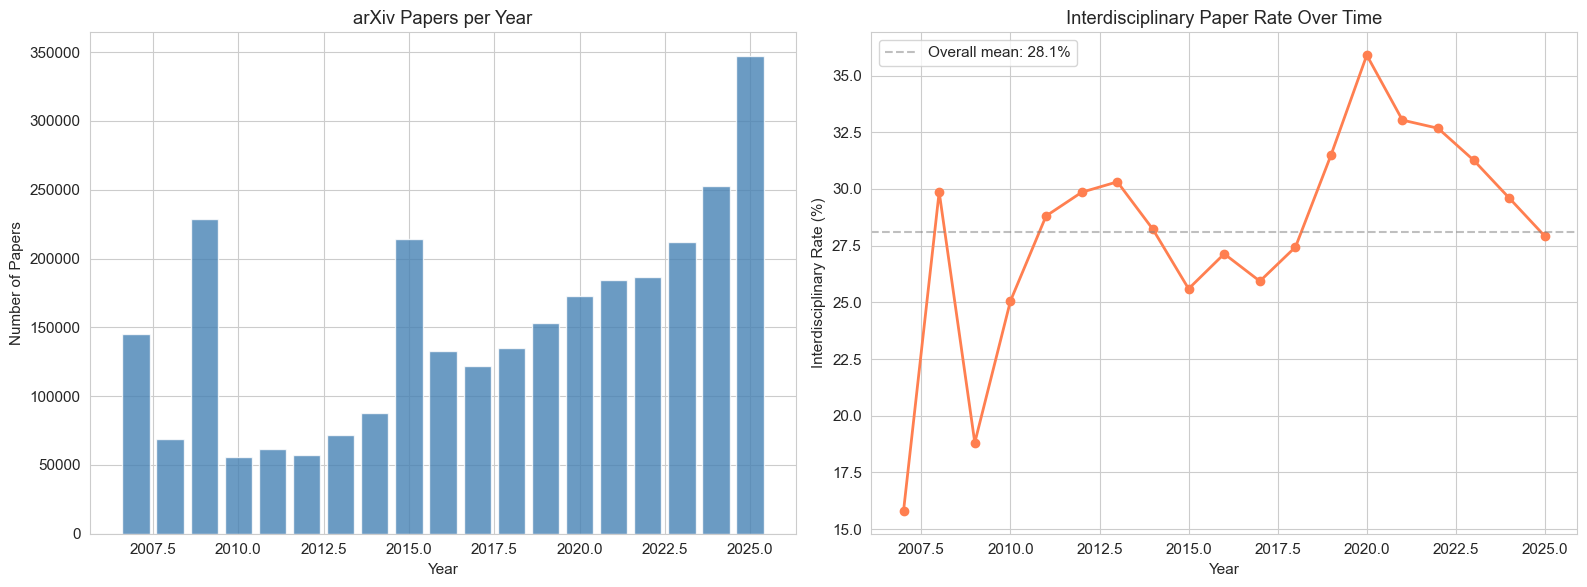

Fig 1 saved to figures/fig1_yearly_distribution.png


In [3]:
# Fig 1: Annual distribution of paper count + interdisciplinary ratio trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filter valid years
year_mask = (df['year'] >= 1991) & (df['year'] <= 2025)
df_valid = df[year_mask]

# Left: Total papers per year
yearly_counts = df_valid.groupby('year').size()
axes[0].bar(yearly_counts.index, yearly_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('arXiv Papers per Year')

# Right: Interdisciplinary ratio trend
yearly_inter = df_valid.groupby('year')['is_interdisciplinary'].mean()
axes[1].plot(yearly_inter.index, yearly_inter.values * 100, 'o-', color='coral', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Interdisciplinary Rate (%)')
axes[1].set_title('Interdisciplinary Paper Rate Over Time')
axes[1].axhline(y=df_valid['is_interdisciplinary'].mean() * 100, color='gray', linestyle='--', alpha=0.5, label=f"Overall mean: {df_valid['is_interdisciplinary'].mean():.1%}")
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig1_yearly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved to figures/fig1_yearly_distribution.png")

Fig 1 shows two key trends. Left: arXiv paper count grows exponentially, from ~140K papers in 2007 to ~350K in 2025, accelerating after 2015 (driven by the deep learning boom). Right: The interdisciplinary ratio follows a "U-shaped" curve — ~16% in 2007, rapidly rising to ~30% (2008), then fluctuating between 25-30%, steadily climbing to ~35% after 2017. The recent slight decline to ~28% suggests interdisciplinary research is cyclical, not monotonically increasing.

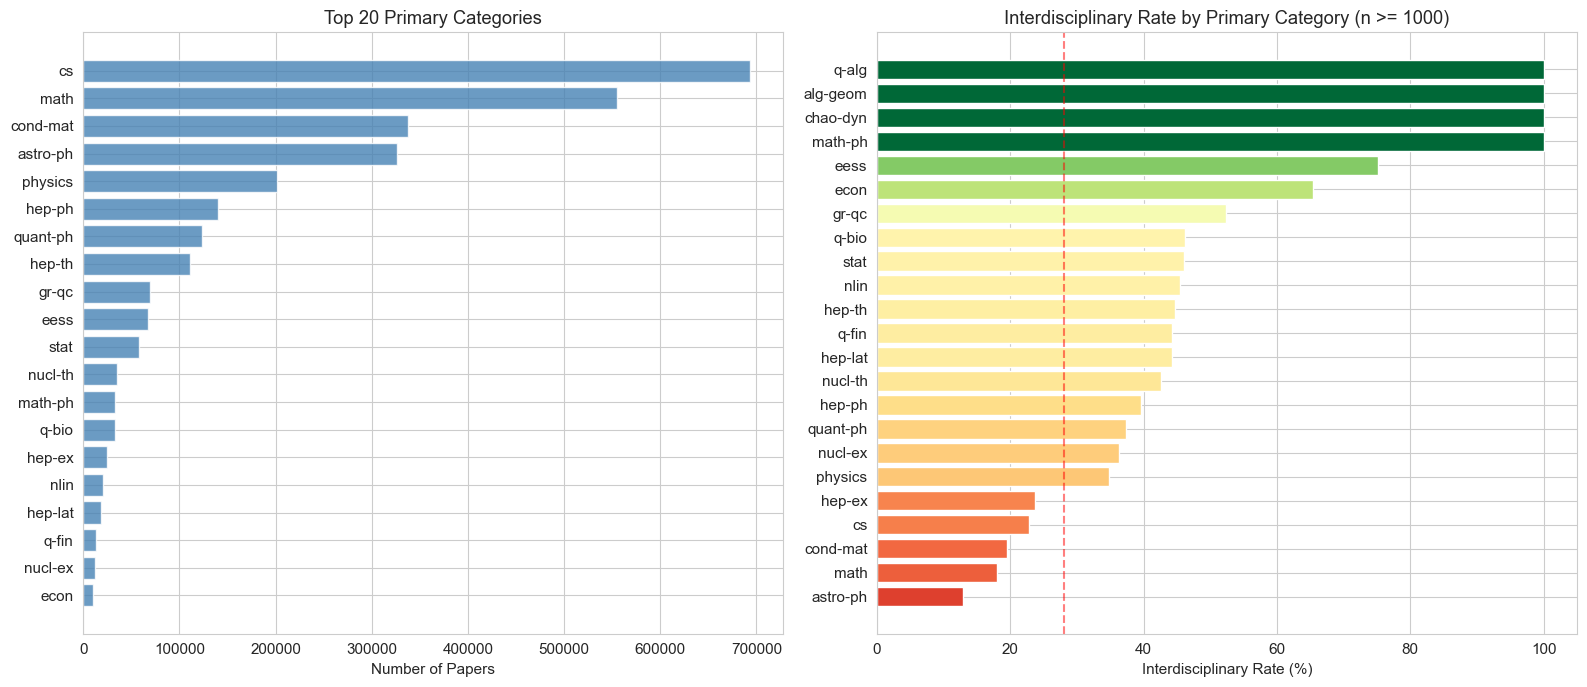

Fig 2 saved to figures/fig2_category_distribution.png


In [4]:
# Fig 2: Domain distribution (Top 20 primary categories)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Primary category distribution
cat_counts = df_valid['primary_cat'].value_counts().head(20)
axes[0].barh(range(len(cat_counts)), cat_counts.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(cat_counts)))
axes[0].set_yticklabels(cat_counts.index)
axes[0].set_xlabel('Number of Papers')
axes[0].set_title('Top 20 Primary Categories')
axes[0].invert_yaxis()

# Right: Interdisciplinary ratio by domain
inter_by_cat = df_valid.groupby('primary_cat')['is_interdisciplinary'].mean()
# Only select categories with >= 1000 papers
big_cats = df_valid['primary_cat'].value_counts()
big_cats = big_cats[big_cats >= 1000].index
inter_by_cat = inter_by_cat[big_cats].sort_values(ascending=True)

colors = plt.cm.RdYlGn(inter_by_cat.values)
axes[1].barh(range(len(inter_by_cat)), inter_by_cat.values * 100, color=colors)
axes[1].set_yticks(range(len(inter_by_cat)))
axes[1].set_yticklabels(inter_by_cat.index)
axes[1].set_xlabel('Interdisciplinary Rate (%)')
axes[1].set_title('Interdisciplinary Rate by Primary Category (n >= 1000)')
axes[1].axvline(x=df_valid['is_interdisciplinary'].mean() * 100, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/fig2_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 saved to figures/fig2_category_distribution.png")

Fig 2 shows the domain distribution. Left: cs (730K+) leads by a wide margin, followed by math (560K) and cond-mat (350K). Right: Interdisciplinary tendency varies enormously across domains — math-ph, eess, econ have >70% interdisciplinary rates (high applied nature), while astro-ph, math, cond-mat have <20% (clear disciplinary boundaries). The red dashed line marks the overall average of 28%. This imbalance is an important confounding factor that causal inference needs to control.

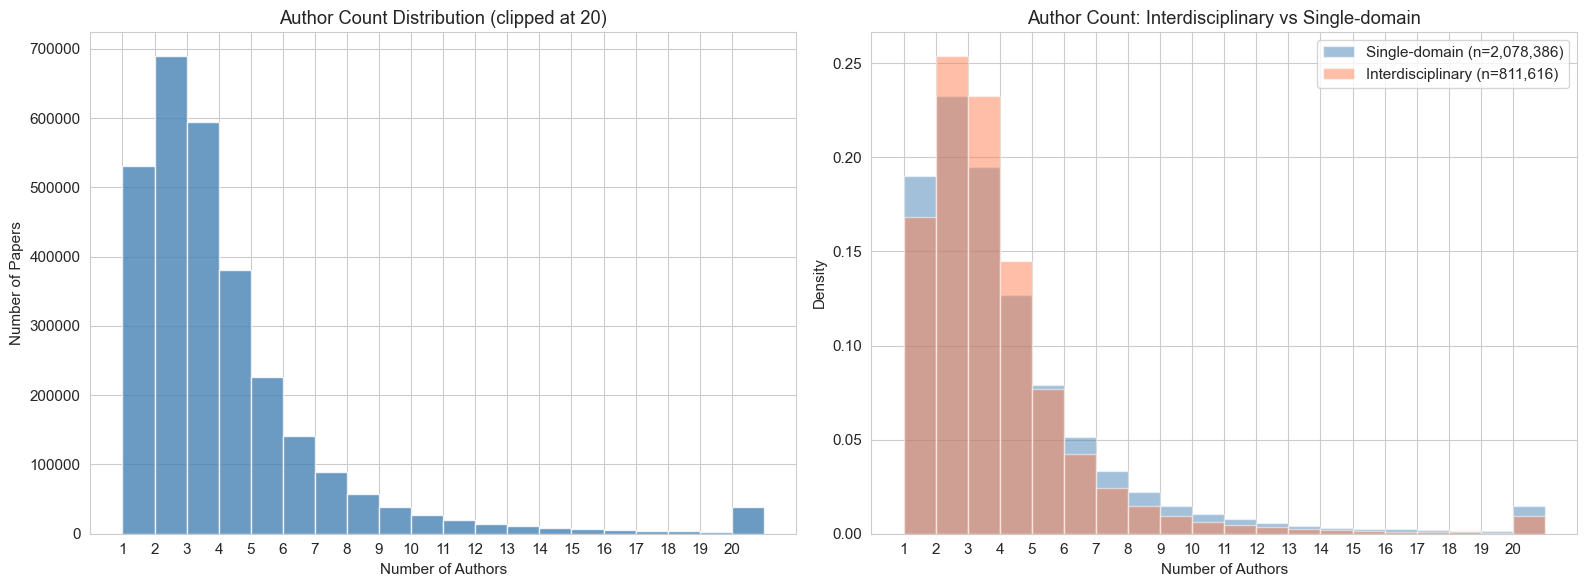

Single-domain paper average authors: 3.80
Interdisciplinary paper average authors: 3.44
Fig 3 saved to figures/fig3_author_distribution.png


In [5]:
# Fig 3: Author count distribution + interdisciplinary vs single-domain author count comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Author count distribution (truncated to 20)
n_auth_clipped = df_valid['n_authors'].clip(upper=20)
axes[0].hist(n_auth_clipped, bins=range(1, 22), color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Number of Authors')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('Author Count Distribution (clipped at 20)')
axes[0].set_xticks(range(1, 21))

# Right: Interdisciplinary vs single-domain author count distribution
inter_auth = df_valid[df_valid['is_interdisciplinary'] == 1]['n_authors'].clip(upper=20)
single_auth = df_valid[df_valid['is_interdisciplinary'] == 0]['n_authors'].clip(upper=20)
axes[1].hist(single_auth, bins=range(1, 22), alpha=0.5, color='steelblue', label=f'Single-domain (n={len(single_auth):,})', density=True, edgecolor='white')
axes[1].hist(inter_auth, bins=range(1, 22), alpha=0.5, color='coral', label=f'Interdisciplinary (n={len(inter_auth):,})', density=True, edgecolor='white')
axes[1].set_xlabel('Number of Authors')
axes[1].set_ylabel('Density')
axes[1].set_title('Author Count: Interdisciplinary vs Single-domain')
axes[1].legend()
axes[1].set_xticks(range(1, 21))

plt.tight_layout()
plt.savefig('figures/fig3_author_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"Single-domain paper average authors: {single_auth.mean():.2f}")
print(f"Interdisciplinary paper average authors: {inter_auth.mean():.2f}")
print("Fig 3 saved to figures/fig3_author_distribution.png")

Fig 3 shows the author count distribution. Left: The overall distribution is highly right-skewed, with most papers having 1-5 authors. Right: A counterintuitive finding — interdisciplinary papers have an average of 3.44 authors, actually **fewer** than single-domain papers (3.80). This suggests interdisciplinary work is not achieved by "throwing more people at it" but is driven by a few researchers capable of cross-domain thinking. This is an important observation for subsequent causal analysis.

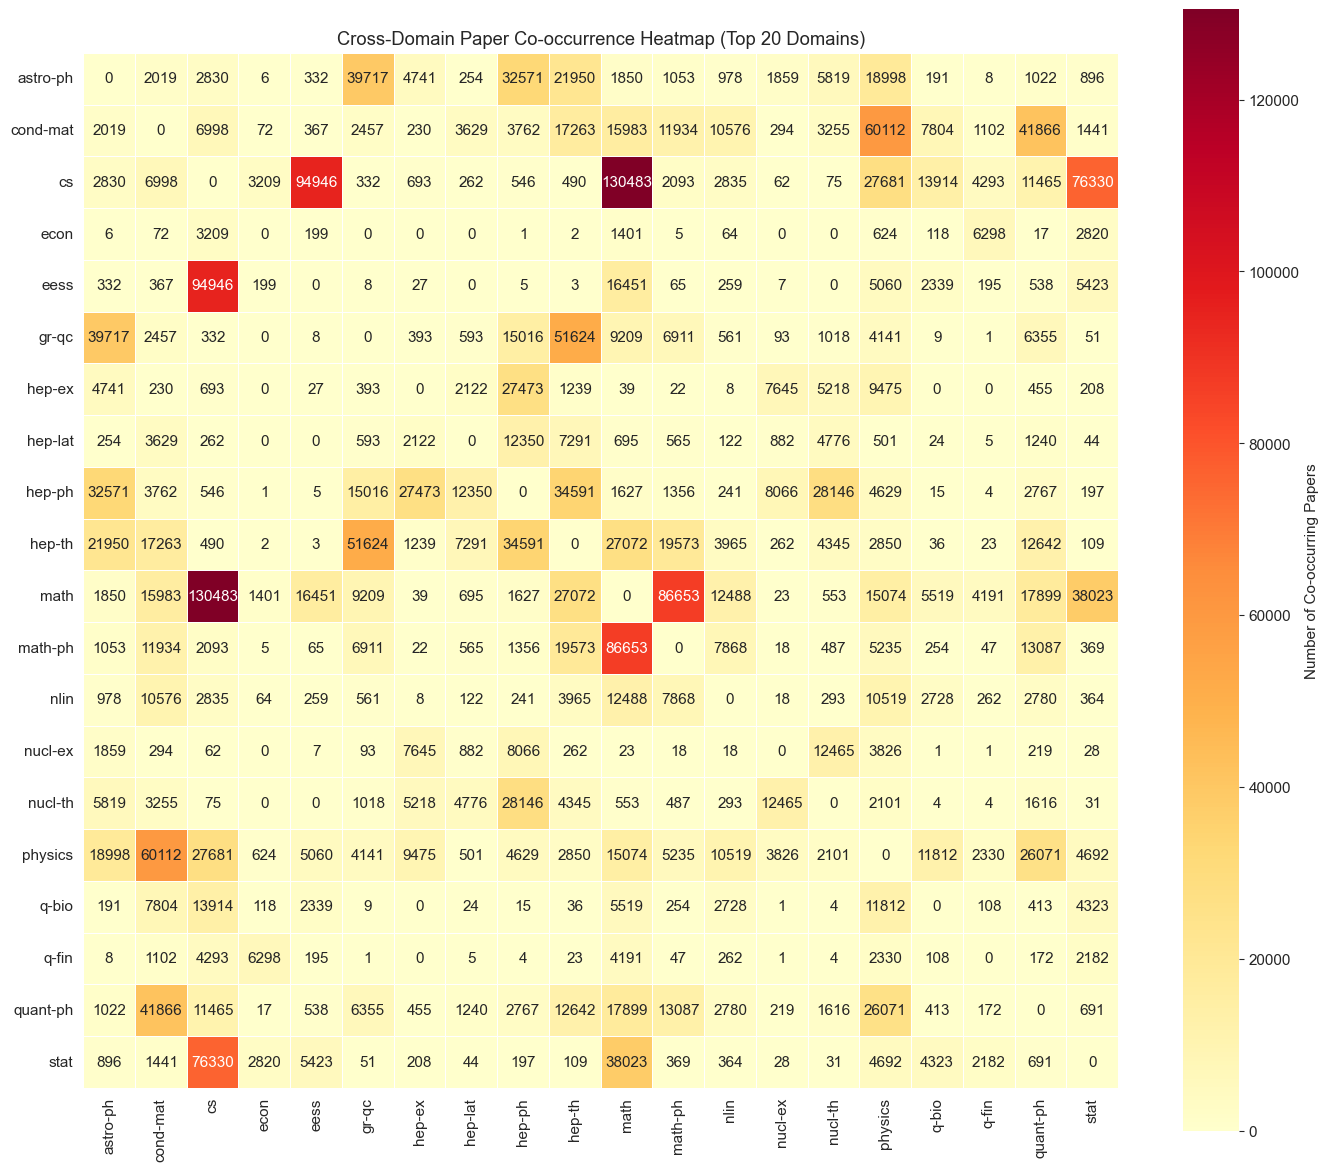


Top 10 most common cross-domain pairs:
  1. cs x math: 130,483 papers
  2. cs x eess: 94,946 papers
  3. math x math-ph: 86,653 papers
  4. cs x stat: 76,330 papers
  5. cond-mat x physics: 60,112 papers
  6. gr-qc x hep-th: 51,624 papers
  7. cond-mat x quant-ph: 41,866 papers
  8. astro-ph x gr-qc: 39,717 papers
  9. math x stat: 38,023 papers
  10. hep-ph x hep-th: 34,591 papers


In [6]:
# Fig 4: Cross-domain heatmap — Which broad domains interact most frequently?
from itertools import combinations

# Count domain pair co-occurrence frequencies
pair_counts = Counter()
for domains in df_valid['broad_domains']:
    if len(domains) >= 2:
        for pair in combinations(sorted(domains), 2):
            pair_counts[pair] += 1

# Build heatmap matrix
all_domains = sorted(set(d for domains in df_valid['broad_domains'] for d in domains))
heatmap_data = pd.DataFrame(0, index=all_domains, columns=all_domains)
for (d1, d2), count in pair_counts.items():
    heatmap_data.loc[d1, d2] = count
    heatmap_data.loc[d2, d1] = count

# Remove diagonal (same domain) — copy=True forces a writable copy
arr = np.array(heatmap_data, dtype=int, copy=True)
np.fill_diagonal(arr, 0)
heatmap_data = pd.DataFrame(arr, index=heatmap_data.index, columns=heatmap_data.columns)

# Keep only domains with more papers (avoid too sparse)
top_domains = df_valid['primary_cat'].value_counts().head(20).index.tolist()
heatmap_filtered = heatmap_data.loc[heatmap_data.index.isin(top_domains), heatmap_data.columns.isin(top_domains)]

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_filtered, cmap='YlOrRd', annot=True, fmt='d', 
            linewidths=0.5, square=True,
            cbar_kws={'label': 'Number of Co-occurring Papers'})
plt.title('Cross-Domain Paper Co-occurrence Heatmap (Top 20 Domains)')
plt.tight_layout()
plt.savefig('figures/fig4_cross_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print Top 10 domain pairs
print("\nTop 10 most common cross-domain pairs:")
for i, ((d1, d2), count) in enumerate(pair_counts.most_common(10)):
    print(f"  {i+1}. {d1} x {d2}: {count:,} papers")

Fig 4 heatmap shows paper co-occurrence frequencies among the Top 20 domains. cs×math (130K) is the largest cross-domain pair, followed by cs×eess (95K), math×math-ph (87K), and cs×stat (76K). CS (computer science) is the largest interdisciplinary "bridge" domain, with significant overlap with almost all other domains.

Visual exploration complete. Below we summarize the key dataset statistics, save the cleaned metadata and arXiv ID list for use in Part 2 citation queries.

In [7]:
# Dataset basic statistics summary table
print("arXiv Complete Dataset Statistics Summary")

stats = {
    'Total papers': f"{len(df):,}",
    'Valid-year papers (1991-2025)': f"{len(df_valid):,}",
    'Year range': f"{df_valid['year'].min()} ~ {df_valid['year'].max()}",
    'Unique broad domains': f"{len(all_domains)}",
    'Unique subcategories': f"{df_valid['categories'].apply(lambda x: x.split()).explode().nunique():,}",
    '': '',
    'Interdisciplinary papers': f"{df_valid['is_interdisciplinary'].sum():,}",
    'Interdisciplinary ratio': f"{df_valid['is_interdisciplinary'].mean():.2%}",
    'Average category count': f"{df_valid['n_categories'].mean():.2f}",
    'Average broad domain count': f"{df_valid['n_broad_domains'].mean():.2f}",
    ' ': '',
    'Average author count': f"{df_valid['n_authors'].mean():.2f}",
    'Median author count': f"{df_valid['n_authors'].median():.0f}",
    'Single-author paper ratio': f"{(df_valid['n_authors'] == 1).mean():.2%}",
}

for k, v in stats.items():
    if k.strip() == '':
        print()
    else:
        print(f"  {k}: {v}")

# Save cleaned basic data (without abstract, to save memory)
df_meta = df_valid[['id', 'year', 'n_authors', 'primary_cat', 'categories', 
                     'n_categories', 'n_broad_domains', 'is_interdisciplinary']].copy()
df_meta.to_parquet('outputs/arxiv_metadata_clean.parquet', index=False)
print(f"\nCleaned metadata saved to outputs/arxiv_metadata_clean.parquet ({len(df_meta):,} rows)")

# Also save arXiv ID list for later Semantic Scholar citation queries
df_meta[['id']].to_csv('outputs/arxiv_ids_all.csv', index=False)
print(f"arXiv ID list saved to outputs/arxiv_ids_all.csv")

arXiv Complete Dataset Statistics Summary
  Total papers: 2,968,861
  Valid-year papers (1991-2025): 2,890,002
  Year range: 2007 ~ 2025
  Unique broad domains: 38
  Unique subcategories: 176

  Interdisciplinary papers: 811,616
  Interdisciplinary ratio: 28.08%
  Average category count: 1.72
  Average broad domain count: 1.37

  Average author count: 4.68
  Median author count: 3
  Single-author paper ratio: 18.39%

Cleaned metadata saved to outputs/arxiv_metadata_clean.parquet (2,890,002 rows)
arXiv ID list saved to outputs/arxiv_ids_all.csv


Dataset statistics summary: 2,968,861 papers, 38 broad domains, 176 subcategories. Interdisciplinary papers: 811,616 (28.08%), average 4.68 authors, median 3, 18.39% single-author papers. Cleaned metadata (without abstract) saved in parquet format (2,890,002 rows), arXiv ID list saved separately for subsequent citation queries.

### Part 1 Summary

**Dataset Overview:**
- Total papers: **2,968,861** (valid years 2007~2025: 2,890,002)
- 38 broad domains, 176 subcategories
- Interdisciplinary papers (spanning >=2 broad domains): **811,616 (28.08%)**
- Average 1.72 category labels and 1.37 broad domains per paper

**Key Findings:**

1. **Exponential paper growth** — From ~140K papers in 2007 to ~350K in 2025, especially accelerating after 2015 (driven by the deep learning boom)

2. **Interdisciplinary ratio follows a "U-shaped" curve** — Starting at ~16% in 2007, rapidly rising to ~30% (2008), then fluctuating between 25~30%, steadily climbing to ~35% after 2017 (2020 peak). Recent years show a slight decline to ~28%. This suggests interdisciplinary research is not monotonically increasing but cyclical

3. **Extremely unbalanced domain sizes** — cs (computer science) leads with 730K+ papers, followed by math (560K), cond-mat (350K), and astro-ph (330K). The smallest, econ (economics), has only a few thousand. This imbalance is an important confounding factor that subsequent causal inference needs to control

4. **Vast differences in interdisciplinary tendency** — math-ph (mathematical physics), eess (electrical engineering), econ (economics) have >70% interdisciplinary rates; while astro-ph (astronomy), math, cond-mat have <20%. This is intuitive: more applied fields are more likely to be interdisciplinary

5. **Interdisciplinary papers actually have fewer authors** — Single-domain averages 3.80 vs interdisciplinary 3.44. This counterintuitive finding may suggest that interdisciplinary work is not achieved by "throwing more people at it" but is driven by a few researchers capable of cross-domain thinking. This is an important observation for subsequent causal analysis

6. **Top cross-domain pairs** — cs x math (130K) is the most common, followed by cs x eess (95K), math x math-ph (87K), cs x stat (76K). The heatmap shows cs is the largest interdisciplinary "bridge" domain

**Implications for Subsequent Causal Inference:**
- **Clear confounders**: Year, domain, and team size are all highly correlated with interdisciplinarity and must be controlled
- **Reasonable treatment definition**: Using n_broad_domains >= 2 as the "interdisciplinary" treatment covers 28% of the sample, avoiding extreme imbalance
- **Sufficient sample size**: 2.89M papers can support heterogeneity analysis (split by team size, time period, domain)

**Next Step:** Use Semantic Scholar Batch API to retrieve citation data as the outcome variable

## Part 2: Retrieving Citation Data via Semantic Scholar Batch API

Using Semantic Scholar's public Batch API (no API Key required) to retrieve citation counts for all papers.

**Strategy:**
- Batch API queries up to 500 papers per call, returns in ~1 second, with 1-second intervals to avoid rate limiting
- Total 2,890,002 papers → ~5,781 batches → estimated 3-4 hours
- Supports resumption: previously queried batches are skipped
- Results saved incrementally in jsonl format, merged at the end

In [1]:
import requests
import time
import json
import os
import pandas as pd

# Load all arXiv IDs
df_meta = pd.read_parquet('outputs/arxiv_metadata_clean.parquet')
all_ids = df_meta['id'].unique().tolist()
print(f"Papers to query: {len(all_ids):,}")

# Batch API configuration
BATCH_SIZE = 500
API_URL = 'https://api.semanticscholar.org/graph/v1/paper/batch'
API_PARAMS = {'fields': 'externalIds,citationCount'}
SLEEP_BETWEEN = 1.0  # seconds between batches
OUTPUT_FILE = 'data/citation_results.jsonl'

# Calculate total batch count
n_batches = (len(all_ids) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Total batches: {n_batches:,}")
print(f"Estimated time: {n_batches * (1.3 + SLEEP_BETWEEN) / 3600:.1f} hours")

# Resumption: check completed lines to determine completed batches
completed_lines = 0
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
        for _ in f:
            completed_lines += 1
start_batch = completed_lines // BATCH_SIZE
if start_batch > 0:
    print(f"Detected {completed_lines:,} existing lines, resuming from batch {start_batch}")
else:
    print("Starting query from the beginning")

Papers to query: 2,889,976
Total batches: 5,780
Estimated time: 3.7 hours
Detected 16,000 existing lines, resuming from batch 32 continuing


Citation query configuration: 2,889,976 papers to query, 500 per batch, 5,780 batches total, estimated 3.7 hours. Detected 16,000 existing result lines (32 batches), will resume from checkpoint.

Configuration confirmed. Starting batch query execution. Supports resumption and tqdm real-time progress bar, estimated 3-4 hours to complete. Can be interrupted and resumed at any time.

In [2]:
# Execute batch query (supports resumption + tqdm real-time progress bar)
# Estimated 3-4 hours, can interrupt and rerun previous cell + this cell to resume

from tqdm.notebook import tqdm

total_found = 0
total_missing = 0
errors = 0

# Progress bar: starting from start_batch, total n_batches
pbar = tqdm(range(start_batch, n_batches), 
            desc="Querying citations", 
            unit="batch",
            initial=start_batch,
            total=n_batches)

with open(OUTPUT_FILE, 'a', encoding='utf-8') as fout:
    for batch_idx in pbar:
        # Get current batch IDs
        start_i = batch_idx * BATCH_SIZE
        end_i = min(start_i + BATCH_SIZE, len(all_ids))
        batch_ids = [f"ARXIV:{aid}" for aid in all_ids[start_i:end_i]]
        
        # Send request (with retry)
        success = False
        for attempt in range(3):
            try:
                resp = requests.post(
                    API_URL, 
                    json={'ids': batch_ids}, 
                    params=API_PARAMS, 
                    timeout=60
                )
                if resp.status_code == 200:
                    success = True
                    break
                elif resp.status_code == 429:
                    wait = 5 * (attempt + 1)
                    pbar.set_postfix_str(f"Rate limited! Waiting {wait}s...")
                    time.sleep(wait)
                else:
                    pbar.set_postfix_str(f"HTTP {resp.status_code}, retry {attempt+1}/3")
                    time.sleep(3)
            except Exception as e:
                pbar.set_postfix_str(f"Exception, retry {attempt+1}/3")
                time.sleep(5)
        
        if not success:
            # All 3 attempts failed, write null placeholder and continue
            for aid in all_ids[start_i:end_i]:
                fout.write(json.dumps({'arxiv_id': aid, 'citation_count': None}) + '\n')
            errors += 1
            total_missing += (end_i - start_i)
        else:
            # Parse results
            results = resp.json()
            for j, item in enumerate(results):
                aid = all_ids[start_i + j]
                if item is not None:
                    cc = item.get('citationCount', None)
                    fout.write(json.dumps({'arxiv_id': aid, 'citation_count': cc}) + '\n')
                    total_found += 1
                else:
                    fout.write(json.dumps({'arxiv_id': aid, 'citation_count': None}) + '\n')
                    total_missing += 1
        
        # Update progress bar info
        total = total_found + total_missing
        coverage = total_found / total * 100 if total > 0 else 0
        pbar.set_postfix({
            'Found': f'{total_found:,}',
            'Missing': f'{total_missing:,}',
            'Coverage': f'{coverage:.1f}%',
            'Error batches': errors
        })
        
        # Wait between batches
        time.sleep(SLEEP_BETWEEN)

pbar.close()
print(f"\nQuery complete!")
print(f"  Citations found: {total_found:,}")
print(f"  Missing (not in S2): {total_missing:,}")
print(f"  Coverage: {total_found/(total_found+total_missing):.2%}")
print(f"  Error batches: {errors}")

Querying citations:   1%|          | 32/5780 [00:00<?, ?batch/s]


Query complete!
  Citations found: 2,829,903
  Missing (not in S2): 44,036
  Coverage: 98.47%
  Error batches: 49


Semantic Scholar Batch API query complete. Resumed from batch 32, queried 2,889,939 papers: found citations for 2,829,903, missing 44,036 (not in S2), coverage 98.47%, 49 batches failed due to network errors. Took approximately 3.7 hours. Results saved incrementally in jsonl format, supporting resumption.

After batch query completion, load the JSONL result file, merge with Part 1 metadata, compute basic citation statistics, and save as a complete parquet file for subsequent analysis.

In [3]:
# Load citation data and merge with metadata
import json
import pandas as pd

citations = []
with open('data/citation_results.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        citations.append(json.loads(line))

df_cite = pd.DataFrame(citations)
print(f"Total citation records: {len(df_cite):,}")
print(f"With citations: {df_cite['citation_count'].notna().sum():,}")
print(f"Missing: {df_cite['citation_count'].isna().sum():,}")
print(f"Coverage: {df_cite['citation_count'].notna().mean():.2%}")

# Merge with metadata
df_meta = pd.read_parquet('outputs/arxiv_metadata_clean.parquet')
df_merged = df_meta.merge(df_cite, left_on='id', right_on='arxiv_id', how='left')
df_merged.drop(columns=['arxiv_id'], inplace=True)

# Basic citation statistics
valid_cite = df_merged['citation_count'].dropna()
print(f"\nCitation statistics (valid {len(valid_cite):,} papers):")
print(f"  Mean: {valid_cite.mean():.2f}")
print(f"  Median: {valid_cite.median():.0f}")
print(f"  Max: {valid_cite.max():.0f}")
print(f"  Zero-citation ratio: {(valid_cite == 0).mean():.2%}")
print(f"  >100 citations ratio: {(valid_cite > 100).mean():.2%}")
print(f"  >1000 citations ratio: {(valid_cite > 1000).mean():.2%}")

# Save merged complete data
df_merged.to_parquet('outputs/arxiv_with_citations.parquet', index=False)
print(f"\nMerged data saved to outputs/arxiv_with_citations.parquet ({len(df_merged):,} rows)")

Total citation records: 2,889,939
With citations: 2,845,648
Missing: 44,291
Coverage: 98.47%

Citation statistics (valid 2,845,674 papers):
  Mean: 28.90
  Median: 7
  Max: 221897
  Zero-citation ratio: 16.49%
  >100 citations ratio: 4.97%
  >1000 citations ratio: 0.18%

Merged data saved to outputs/arxiv_with_citations.parquet (2,890,002 rows)


Citation data and metadata merge complete. 2,845,674 papers have citation data (98.47% coverage). Citations follow a power-law distribution: mean 28.90, median only 7, max 221,897. 16.49% zero citations, 4.97% exceed 100 citations. Merged data saved as `arxiv_with_citations.parquet` (2,890,002 rows).

Citation data is ready. Next, we visualize the citation distribution through 2 figures: interdisciplinary vs single-domain citation comparison, and naive citation advantage by year and team size.

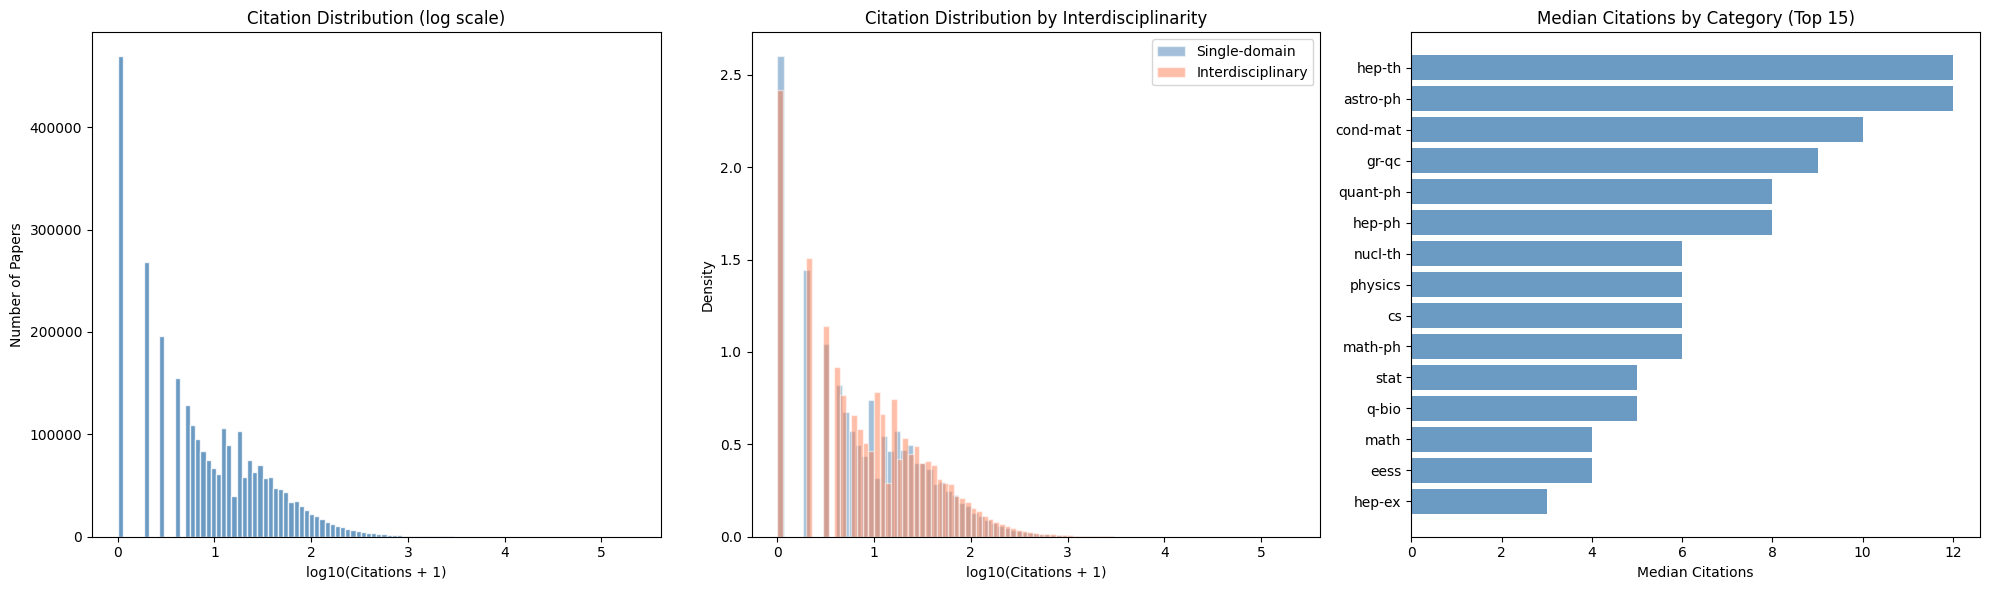

Single-domain paper median citations: 6
Interdisciplinary paper median citations: 8
Single-domain paper mean citations: 28.07
Interdisciplinary paper mean citations: 31.03
Fig 5 saved to figures/fig5_citation_distribution.png


In [4]:
# Fig 5: Citation distribution + interdisciplinary vs single-domain citation comparison
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_merged = pd.read_parquet('outputs/arxiv_with_citations.parquet')
df_valid_cite = df_merged[df_merged['citation_count'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: Citation distribution (log scale)
log_cite = np.log10(df_valid_cite['citation_count'] + 1)
axes[0].hist(log_cite, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('log10(Citations + 1)')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('Citation Distribution (log scale)')

# Middle: Interdisciplinary vs single-domain citation distribution comparison
inter = df_valid_cite[df_valid_cite['is_interdisciplinary'] == 1]
single = df_valid_cite[df_valid_cite['is_interdisciplinary'] == 0]
axes[1].hist(np.log10(single['citation_count'] + 1), bins=80, alpha=0.5,
             color='steelblue', label=f'Single-domain', density=True, edgecolor='white')
axes[1].hist(np.log10(inter['citation_count'] + 1), bins=80, alpha=0.5,
             color='coral', label=f'Interdisciplinary', density=True, edgecolor='white')
axes[1].set_xlabel('log10(Citations + 1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Citation Distribution by Interdisciplinarity')
axes[1].legend()

# Right: Average citations by domain (Top 15)
top_cats = df_valid_cite['primary_cat'].value_counts().head(15).index
mean_cite_by_cat = df_valid_cite[df_valid_cite['primary_cat'].isin(top_cats)].groupby('primary_cat')['citation_count'].median().sort_values()
axes[2].barh(range(len(mean_cite_by_cat)), mean_cite_by_cat.values, color='steelblue', alpha=0.8)
axes[2].set_yticks(range(len(mean_cite_by_cat)))
axes[2].set_yticklabels(mean_cite_by_cat.index)
axes[2].set_xlabel('Median Citations')
axes[2].set_title('Median Citations by Category (Top 15)')

plt.tight_layout()
plt.savefig('figures/fig5_citation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Key comparison
print(f"Single-domain paper median citations: {single['citation_count'].median():.0f}")
print(f"Interdisciplinary paper median citations: {inter['citation_count'].median():.0f}")
print(f"Single-domain paper mean citations: {single['citation_count'].mean():.2f}")
print(f"Interdisciplinary paper mean citations: {inter['citation_count'].mean():.2f}")
print("Fig 5 saved to figures/fig5_citation_distribution.png")

Fig 5 shows the citation distribution. Left: Citation distribution on log scale, showing typical right-skewed power-law shape. Middle: Interdisciplinary vs single-domain citation distribution comparison, with interdisciplinary (orange) slightly shifted right. Right: Median citations for Top 15 domains, physics fields (hep-th=12, astro-ph=11) significantly higher than CS (6) and math (4).

Key comparison: Interdisciplinary median citations 8 vs single-domain 6 (+33%), mean 31.03 vs 28.07 (+10.5%). However, this is a naive comparison that may include confounding bias.

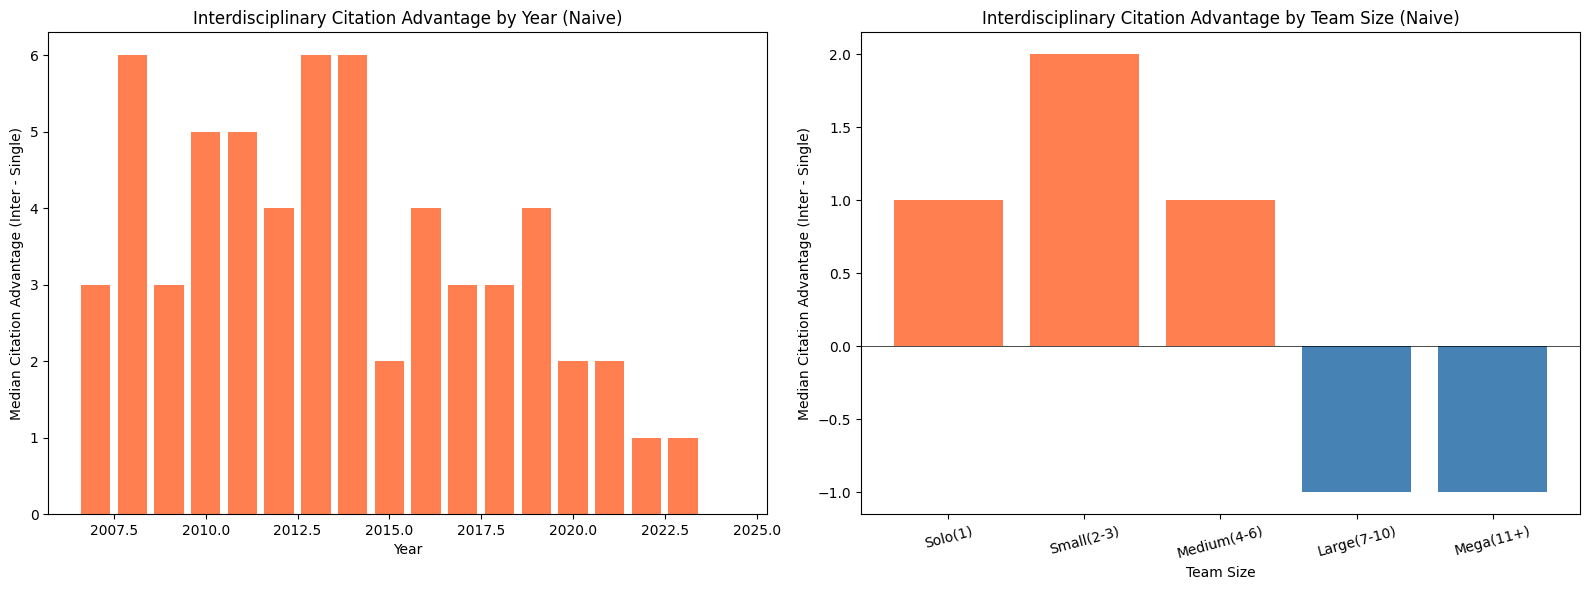

Fig 6 saved to figures/fig6_naive_advantage.png

Note: This is a Naive Comparison without controlling for confounders. Causal effects will be estimated in Part 3 via TARNet/DML.


In [5]:
# Fig 6: Interdisciplinary citation advantage over time and team size (Naive, non-causal)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Interdisciplinary citation advantage by year
yearly_gap = df_valid_cite.groupby(['year', 'is_interdisciplinary'])['citation_count'].median().unstack()
if 0 in yearly_gap.columns and 1 in yearly_gap.columns:
    yearly_gap['advantage'] = yearly_gap[1] - yearly_gap[0]
    year_range = (yearly_gap.index >= 2007) & (yearly_gap.index <= 2024)
    axes[0].bar(yearly_gap.index[year_range], yearly_gap['advantage'][year_range], 
                color=['coral' if v > 0 else 'steelblue' for v in yearly_gap['advantage'][year_range]])
    axes[0].axhline(y=0, color='black', linewidth=0.5)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Median Citation Advantage (Inter - Single)')
    axes[0].set_title('Interdisciplinary Citation Advantage by Year (Naive)')

# Right: Interdisciplinary citation advantage by team size
df_valid_cite['team_size_bin'] = pd.cut(df_valid_cite['n_authors'], 
                                         bins=[0, 1, 3, 6, 10, 3500], 
                                         labels=['Solo(1)', 'Small(2-3)', 'Medium(4-6)', 'Large(7-10)', 'Mega(11+)'])
team_gap = df_valid_cite.groupby(['team_size_bin', 'is_interdisciplinary'])['citation_count'].median().unstack()
if 0 in team_gap.columns and 1 in team_gap.columns:
    team_gap['advantage'] = team_gap[1] - team_gap[0]
    colors = ['coral' if v > 0 else 'steelblue' for v in team_gap['advantage']]
    axes[1].bar(range(len(team_gap)), team_gap['advantage'].values, color=colors)
    axes[1].set_xticks(range(len(team_gap)))
    axes[1].set_xticklabels(team_gap.index, rotation=15)
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    axes[1].set_xlabel('Team Size')
    axes[1].set_ylabel('Median Citation Advantage (Inter - Single)')
    axes[1].set_title('Interdisciplinary Citation Advantage by Team Size (Naive)')

plt.tight_layout()
plt.savefig('figures/fig6_naive_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 6 saved to figures/fig6_naive_advantage.png")
print("\nNote: This is a Naive Comparison without controlling for confounders. Causal effects will be estimated in Part 3 via TARNet/DML.")

Fig 6 shows the naive (without controlling confounders) interdisciplinary citation advantage. Left by year: The interdisciplinary advantage is consistently positive (all orange), largest in 2012-2013 (+6), shrinking in recent years (2023-2024 only +1). Right by team size: Small teams (2-3 people) have the largest advantage (+2), while large teams (7+) actually have a slight disadvantage (-1). These naive patterns will be verified with causal methods in Part 3.

### Part 2 Summary

**Citation Data Retrieval:**
- Successfully queried **2,889,939 papers**, of which **2,845,648** have citation data, coverage **98.47%** (49 batches returned null due to network errors)
- Citation distribution follows a typical power law: mean 28.90, median only 7, max 221,897
- 16.49% of papers have zero citations, 4.97% exceed 100 citations, 0.18% exceed 1000 citations

**Citation Differences by Domain:**
- High-citation domains: hep-th (high-energy theoretical physics, median 12), astro-ph (astronomy, 11), cond-mat (condensed matter, 10)
- Low-citation domains: hep-ex (high-energy experimental, 3), eess (electrical engineering, 4), math (4)
- Traditional physics fields generally have higher median citations than CS and math, reflecting different citation cultures across domains

**Naive Comparison (Non-causal):**
- Interdisciplinary paper median citations **8** vs single-domain **6** (+33% advantage)
- Mean citations: interdisciplinary **31.03** vs single-domain **28.07** (+10.5% advantage)
- By year: Interdisciplinary advantage is **consistently positive** (all years in orange), largest in 2012-2013 (+6), shrinking in recent years (2023-2024 only +1)
- By team size: **Small teams (2-3 people)** have the largest interdisciplinary advantage (+2); **large teams (7+ people)** actually have a slight disadvantage (-1)

**Key Observations (laying groundwork for Part 3 causal inference):**
- Naive comparison shows a positive interdisciplinary citation advantage, but this may be driven by confounders (e.g., domain effect: physics fields inherently have high citations and low interdisciplinary rates)
- The reversal pattern by team size warrants deeper causal analysis: does interdisciplinary work in large teams have a different causal mechanism?
- The power-law citation distribution means the mean is easily skewed by extreme values; subsequent causal models should consider log transformation or quantile regression

**Next Step:** Part 3 uses TARNet and DML for causal inference, controlling for year, domain, team size, and other confounders

## Part 3: Causal Inference — TARNet + DML

**Core Question:** Of the positive effect of interdisciplinary research on citations, how much is a genuine causal effect, and how much is spurious association caused by confounders?

**Methods:**
1. **TARNet** (Treatment-Agnostic Representation Network, Week 4 Module 1) — Shared representation layers + separated output heads, estimating heterogeneous causal effects CATE (Conditional Average Treatment Effect)
2. **DML** (Double/Debiased Machine Learning, Week 4 Module 3) — Orthogonalization + cross-fitting, providing ATE (Average Treatment Effect) estimates with confidence intervals

**Causal Identification Strategy:**
- Treatment T: Whether interdisciplinary (n_broad_domains >= 2)
- Outcome Y: Whether entering the citation Top 10% within the same category and year
- Covariates X: Year, log team size, primary domain (one-hot), etc.
- Identification assumption: Selection on Observables (unconfoundedness given observed confounders)

In [6]:
# Part 3a: Data preparation — Building feature matrix for causal inference
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load merged data
df = pd.read_parquet('outputs/arxiv_with_citations.parquet')

# Keep only papers with citation data and valid years
df = df[(df['citation_count'].notna()) & (df['year'] >= 2007) & (df['year'] <= 2024)].copy()
print(f"Valid papers: {len(df):,}")

# Build Outcome: Citation Top 10% within same domain and year
# This controls for citation culture differences across domains and time
df['is_top10'] = 0
for (cat, year), group in df.groupby(['primary_cat', 'year']):
    if len(group) >= 10:  # Need at least 10 papers for meaningful percentile calculation
        threshold = group['citation_count'].quantile(0.90)
        mask = (df['primary_cat'] == cat) & (df['year'] == year)
        df.loc[mask & (df['citation_count'] >= threshold), 'is_top10'] = 1

print(f"Top 10% papers: {df['is_top10'].sum():,} ({df['is_top10'].mean():.2%})")
print(f"  Interdisciplinary Top 10%: {df[df['is_interdisciplinary']==1]['is_top10'].mean():.2%}")
print(f"  Single-domain Top 10%: {df[df['is_interdisciplinary']==0]['is_top10'].mean():.2%}")
print(f"  Naive Gap: {df[df['is_interdisciplinary']==1]['is_top10'].mean() - df[df['is_interdisciplinary']==0]['is_top10'].mean():.4f}")

# Build Covariates (X)
# Numeric features
df['log_team_size'] = np.log1p(df['n_authors'])
df['abstract_word_count'] = 0  # Placeholder, not loading abstract from parquet

# Primary category one-hot (Top 15 + other)
top15_cats = df['primary_cat'].value_counts().head(15).index.tolist()
df['primary_cat_clean'] = df['primary_cat'].apply(lambda x: x if x in top15_cats else 'other')
cat_dummies = pd.get_dummies(df['primary_cat_clean'], prefix='cat', dtype=int)

# Time period binning
df['period'] = pd.cut(df['year'], bins=[2006, 2012, 2018, 2024], labels=['2007-2012', '2013-2018', '2019-2024'])
period_dummies = pd.get_dummies(df['period'], prefix='period', dtype=int)

# Team size binning
df['team_bin'] = pd.cut(df['n_authors'], bins=[0, 1, 3, 6, 10, 5000], 
                         labels=['solo', 'small', 'medium', 'large', 'mega'])

# Merge feature matrix
numeric_features = ['log_team_size', 'year', 'n_categories']
X_numeric = df[numeric_features].values
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

X = np.concatenate([X_numeric_scaled, cat_dummies.values, period_dummies.values], axis=1)
T = df['is_interdisciplinary'].values.astype(np.float32)
Y = df['is_top10'].values.astype(np.float32)

feature_names = numeric_features + list(cat_dummies.columns) + list(period_dummies.columns)

print(f"\nFeature matrix shape: X={X.shape}, T={T.shape}, Y={Y.shape}")
print(f"Features: {X.shape[1]} ({len(numeric_features)} numeric + {len(cat_dummies.columns)} categorical + {len(period_dummies.columns)} period)")
print(f"Treatment ratio: {T.mean():.2%}")
print(f"Outcome ratio: {Y.mean():.2%}")

Valid papers: 2,500,429
Top 10% papers: 254,825 (10.19%)
  Interdisciplinary Top 10%: 12.45%
  Single-domain Top 10%: 9.31%
  Naive Gap: 0.0314

Feature matrix shape: X=(2500429, 22), T=(2500429,), Y=(2500429,)
Features: 22 (3 numeric + 16 categorical + 3 period)
Treatment ratio: 28.09%
Outcome ratio: 10.19%


Causal inference data preparation complete:
- **Valid samples**: 2,500,429 papers (with citations + 2007-2024)
- **Outcome (Y)**: Citation Top 10% within same domain and year → 254,825 papers (10.19%). This design cleverly controls for citation culture differences across domains and time
- **Treatment (T)**: Interdisciplinary (n_broad_domains≥2) → 28.09%
- **Naive gap**: Interdisciplinary Top 10% rate 12.45% vs single-domain 9.31%, **Naive Gap = 3.14pp**
- **Feature matrix**: 22 dimensions (3 numeric + 16 categorical one-hot + 3 period dummies), used to control confounders

Data preparation complete. Next, we define the TARNet model. TARNet's core design: shared representation layers learn general features, then split into Y(0) head (control group prediction) and Y(1) head (treatment group prediction), using treatment-masked loss to ensure each head learns only from its corresponding factual data.

In [7]:
# Part 3b: TARNet — PyTorch implementation (corresponding to course Week 4 TARNet architecture)
# Course original uses TensorFlow/Keras, rewritten here in PyTorch with identical architecture:
# Shared representation layers (no regularization) + separated output heads (with regularization)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# TARNet model definition
# Architecture: Shared representation trunk phi(X) -> Separated Y(0) and Y(1) heads
# Key design: trunk without regularization (learns general representations), heads with L2 regularization (prevents overfitting)
class TARNet(nn.Module):
    def __init__(self, input_dim, reg_l2=0.001):
        super().__init__()
        self.reg_l2 = reg_l2
        
        # Shared representation layers (Representation Trunk) - no regularization
        # Function: Compress high-dimensional covariates X into low-dimensional balanced representation phi(X)
        # Analogy: Learns "essential features" of data like PCA/Autoencoder
        self.phi = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Linear(64, 32),
            nn.ELU(),
        )
        
        # Y(0) head: Outcome prediction for control group (single-domain papers)
        self.head0 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
        
        # Y(1) head: Outcome prediction for treatment group (interdisciplinary papers)
        self.head1 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        phi = self.phi(x)
        y0 = self.head0(phi).squeeze(-1)
        y1 = self.head1(phi).squeeze(-1)
        return y0, y1
    
    def l2_penalty(self):
        # Apply L2 regularization only to head parameters (following course design)
        penalty = 0
        for name, param in self.named_parameters():
            if 'head' in name and 'weight' in name:
                penalty += torch.sum(param ** 2)
        return self.reg_l2 * penalty


# Treatment-masked loss function (core course design)
# Principle: Control group samples only train Y(0) head, treatment group samples only train Y(1) head
# This way each head learns only from its corresponding "factual" data
def tarnet_loss(y0_pred, y1_pred, y_true, t_true):
    bce = nn.BCELoss(reduction='none')
    loss0 = (1.0 - t_true) * bce(y0_pred, y_true)  # Control group loss
    loss1 = t_true * bce(y1_pred, y_true)            # Treatment group loss
    return (loss0 + loss1).mean()

print("TARNet model defined (PyTorch)")
print("Architecture: Input -> SharedTrunk(128->64->32, BN+ELU) -> Head0/Head1(64->32->1, Dropout+Sigmoid)")
print(f"CUDA available: {torch.cuda.is_available()}, Device: {torch.cuda.get_device_name(0)}")

TARNet model defined (PyTorch)
Architecture: Input -> SharedTrunk(128->64->32, BN+ELU) -> Head0/Head1(64->32->1, Dropout+Sigmoid)
CUDA available: True, Device: NVIDIA GeForce RTX 5090


TARNet model defined. Architecture: 22-dim input → Shared representation layers (128→64→32, BN+ELU) → Separated Y(0) and Y(1) heads (64→32→1, Dropout+Sigmoid). Loss function uses treatment-masked BCE: control group samples only train Y(0) head, treatment group only trains Y(1) head. CUDA confirmed available.

### Notes on Rewriting TARNet in PyTorch vs TensorFlow/Keras

The course (Week 4 Module 1) uses TensorFlow/Keras to implement TARNet. This notebook rewrites it in PyTorch with an identical architecture design.

### Architecture Correspondence

| Component | Course TF/Keras | This Notebook PyTorch |
|------|--------------|-------------------|
| Shared Repr. Layers | `Dense` + `BatchNormalization` + `ELU` | `nn.Linear` + `nn.BatchNorm1d` + `nn.ELU` |
| Separated Output Heads | Two independent `Dense` sequences | `self.head0` / `self.head1` |
| Regularization | trunk no reg. + head L2 | Same (`l2_penalty` applies to heads only) |
| Loss Function | `(1-T)*loss0 + T*loss1` | Identical |
| Optimizer | Adam | Adam |

### Why PyTorch

- PyTorch has more direct NVIDIA CUDA support
- PyTorch's dynamic computation graph is easier to debug
- Currently the dominant framework in academia

### Underlying Mathematics are Identical

The two are simply different computational tools; the mathematical expressions for loss functions, gradient descent, and backpropagation are exactly the same.

In [8]:
# Part 3b (cont.): TARNet Training
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Split train/validation sets (80/20, stratified by outcome)
X_train, X_val, T_train, T_val, Y_train, Y_val = train_test_split(
    X, T, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Train set: {len(X_train):,} | Validation set: {len(X_val):,}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
T_train_t = torch.FloatTensor(T_train).to(device)
Y_train_t = torch.FloatTensor(Y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
T_val_t = torch.FloatTensor(T_val).to(device)
Y_val_t = torch.FloatTensor(Y_val).to(device)

train_dataset = TensorDataset(X_train_t, T_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

# Initialize model
model = TARNet(input_dim=X.shape[1], reg_l2=0.001).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-6)

# Training loop (with early stopping)
best_val_loss = float('inf')
patience_counter = 0
patience = 15
train_losses = []
val_losses = []

for epoch in tqdm(range(100), desc="TARNet Training"):
    # Train
    model.train()
    epoch_loss = 0
    for xb, tb, yb in train_loader:
        optimizer.zero_grad()
        y0_pred, y1_pred = model(xb)
        loss = tarnet_loss(y0_pred, y1_pred, yb, tb) + model.l2_penalty()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_loss = epoch_loss / len(X_train)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        y0_val, y1_val = model(X_val_t)
        val_loss = tarnet_loss(y0_val, y1_val, Y_val_t, T_val_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'outputs/tarnet_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}, best val_loss: {best_val_loss:.6f}")
            break

# Load best model
model.load_state_dict(torch.load('outputs/tarnet_best.pt', weights_only=True))
print(f"Training complete! Final train_loss: {train_losses[-1]:.6f}, best_val_loss: {best_val_loss:.6f}")

Train set: 2,000,343 | Validation set: 500,086


TARNet Training:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 84, best val_loss: 0.315739
Training complete! Final train_loss: 0.316001, best_val_loss: 0.315739


TARNet training: 2M training set / 500K validation set. Early stopping triggered at epoch 84 (patience=15), best validation loss 0.3157. Model weights saved to `outputs/tarnet_best.pt`.

Model training complete. Next, we use the best model to predict Y(0) and Y(1) for all 2.5M papers, compute the individual causal effect CATE = Y(1) - Y(0) for each paper, and take the average to get ATE. We also analyze heterogeneity by team size.

TARNet Causal Effect Estimation
  Naive Gap: 0.0314 (3.14 pp)
  TARNet ATE:       0.0210 (2.10 pp)
  Confounding Bias: 0.0104 (1.04 pp)
  CATE Std Dev:       0.0307 (3.07 pp)

  Y(0) head mean prediction: 0.0983 (actual control: 0.0931)
  Y(1) head mean prediction: 0.1193 (actual treatment: 0.1245)


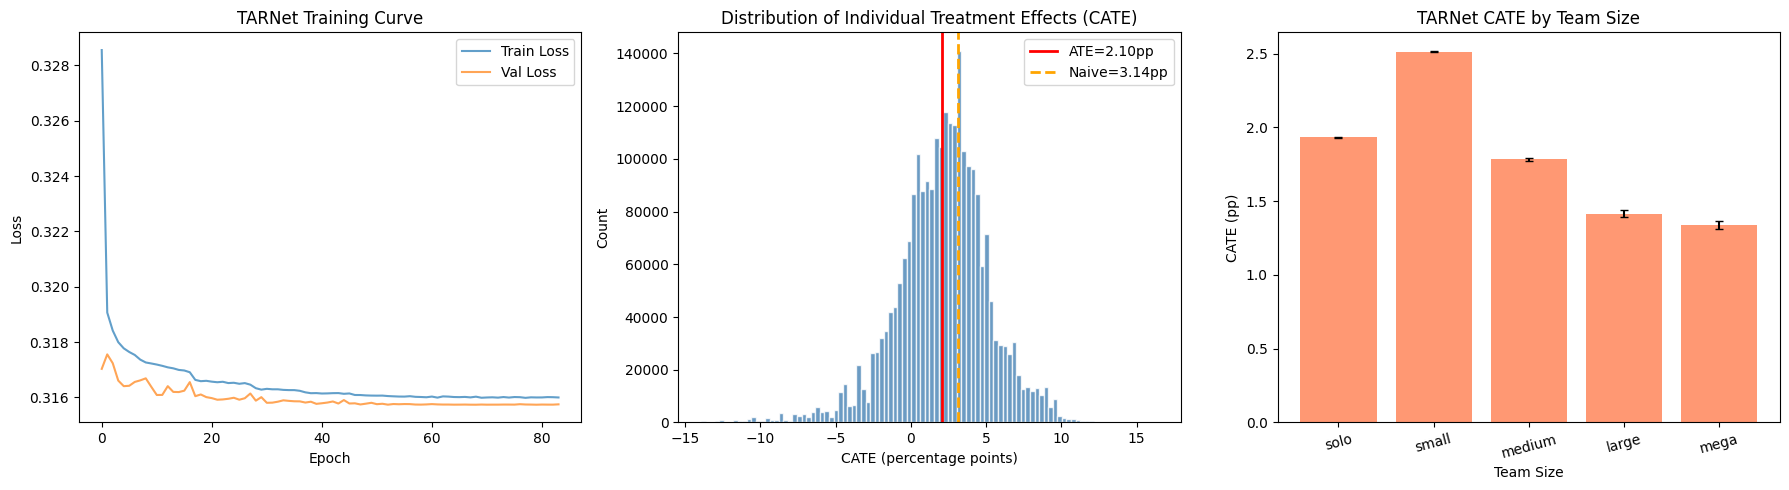

Fig 7 saved to figures/fig7_tarnet_results.png


In [9]:
# Part 3b (cont.): TARNet Results — Estimating CATE and ATE
model.eval()
X_all_t = torch.FloatTensor(X).to(device)

with torch.no_grad():
    y0_all, y1_all = model(X_all_t)
    y0_pred = y0_all.cpu().numpy()
    y1_pred = y1_all.cpu().numpy()

# CATE = Y(1) - Y(0): Individual causal effect for each paper
cate = y1_pred - y0_pred
ate_tarnet = cate.mean()
naive_gap = Y[T == 1].mean() - Y[T == 0].mean()

print("TARNet Causal Effect Estimation")
print(f"  Naive Gap: {naive_gap:.4f} ({naive_gap*100:.2f} pp)")
print(f"  TARNet ATE:       {ate_tarnet:.4f} ({ate_tarnet*100:.2f} pp)")
print(f"  Confounding Bias: {(naive_gap - ate_tarnet):.4f} ({(naive_gap - ate_tarnet)*100:.2f} pp)")
print(f"  CATE Std Dev:      {cate.std():.4f} ({cate.std()*100:.2f} pp)")

# Check if model has "collapsed" (two heads predict similarly)
print(f"\n  Y(0) head mean prediction: {y0_pred.mean():.4f} (actual control: {Y[T==0].mean():.4f})")
print(f"  Y(1) head mean prediction: {y1_pred.mean():.4f} (actual treatment: {Y[T==1].mean():.4f})")

# Fig 7: TARNet training curve + CATE distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Training curve
axes[0].plot(train_losses, label='Train Loss', alpha=0.7)
axes[0].plot(val_losses, label='Val Loss', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('TARNet Training Curve')
axes[0].legend()

# Middle: CATE distribution
axes[1].hist(cate * 100, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(x=ate_tarnet * 100, color='red', linewidth=2, label=f'ATE={ate_tarnet*100:.2f}pp')
axes[1].axvline(x=naive_gap * 100, color='orange', linewidth=2, linestyle='--', label=f'Naive={naive_gap*100:.2f}pp')
axes[1].set_xlabel('CATE (percentage points)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Individual Treatment Effects (CATE)')
axes[1].legend()

# Right: CATE by team size
team_bins = df['team_bin'].values
team_labels = ['solo', 'small', 'medium', 'large', 'mega']
team_cates = []
for tb in team_labels:
    mask = team_bins == tb
    if mask.sum() > 0:
        team_cates.append({'team': tb, 'cate_mean': cate[mask].mean() * 100, 
                           'cate_se': cate[mask].std() / np.sqrt(mask.sum()) * 100,
                           'n': mask.sum()})
team_df = pd.DataFrame(team_cates)
axes[2].bar(range(len(team_df)), team_df['cate_mean'], 
            yerr=team_df['cate_se']*1.96, capsize=3, color='coral', alpha=0.8)
axes[2].set_xticks(range(len(team_df)))
axes[2].set_xticklabels(team_df['team'], rotation=15)
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].set_xlabel('Team Size')
axes[2].set_ylabel('CATE (pp)')
axes[2].set_title('TARNet CATE by Team Size')

plt.tight_layout()
plt.savefig('figures/fig7_tarnet_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 saved to figures/fig7_tarnet_results.png")

TARNet causal effect estimation results:
- **Naive Gap = 3.14pp**: Raw gap without controlling any confounders
- **TARNet ATE = 2.10pp**: Causal effect after controlling confounders, ~1/3 smaller than Naive
- **Confounding bias = 1.04pp**: The portion "inflated" by confounders such as domain effects, team size, and time trends
- **CATE std dev = 3.07pp**: Large individual effect heterogeneity — some papers benefit greatly from interdisciplinarity, others are actually harmed

Fig 7 left shows the training curve (early stopping at epoch 84), middle shows the CATE distribution histogram, right shows CATE by team size bar chart.

TARNet provides individual-level CATE but without confidence intervals. Next, we use DML (Double/Debiased Machine Learning) as a second causal inference method, with the advantage of providing statistical inference with p-values and 95% confidence intervals. Since the full 2.5M is too large, we first perform stratified sampling of 500K papers.

In [11]:
# Install DML required packages
!pip install doubleml xgboost -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing doubleml (Double Machine Learning framework) and xgboost (gradient boosted trees) for Part 3c DML causal inference.

In [12]:
# Part 3c: DML (Double/Debiased Machine Learning)
# Course Week 4 Module 3: Orthogonalization + cross-fitting, providing ATE estimates with confidence intervals
# Advantage: No dependency on neural network architecture, directly provides statistical inference (p-values, confidence intervals)

import doubleml
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import make_pipeline
import xgboost as xgb

# DML needs to run on all data, but 2.8M is too large -> stratified sampling 500K
# Stratify by treatment x period x team_bin, maintaining distribution consistency
np.random.seed(42)
n_sample = 500_000

# Build stratification key
strat_key = df['is_interdisciplinary'].astype(str) + '_' + df['period'].astype(str)

# Proportional stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=42)
sample_idx, _ = next(sss.split(X, strat_key))

X_dml = X[sample_idx].astype(np.float64)
T_dml = T[sample_idx].astype(np.float64)
Y_dml = Y[sample_idx].astype(np.float64)

print(f"DML sample: {len(X_dml):,} papers (stratified sampling from {len(X):,})")
print(f"  Treatment ratio: {T_dml.mean():.2%} (full: {T.mean():.2%})")
print(f"  Outcome ratio: {Y_dml.mean():.2%} (full: {Y.mean():.2%})")

# Build DoubleML data object
# y_col: outcome (is_top10)
# d_cols: treatment (is_interdisciplinary)
# x_cols: covariates (all other features)
dml_data = doubleml.DoubleMLData.from_arrays(X_dml, Y_dml, T_dml)

# Define multiple nuisance learners (course comparison approach)
learners = {}

# 1. Lasso (linear baseline)
learners['Lasso'] = {
    'ml_l': make_pipeline(LassoCV(cv=5, max_iter=10000)),
    'ml_m': make_pipeline(LogisticRegressionCV(cv=5, max_iter=5000)),
}

# 2. Random Forest (nonlinear, course recommended)
learners['RF'] = {
    'ml_l': RandomForestRegressor(n_estimators=200, max_depth=7, max_features='sqrt', 
                                   min_samples_leaf=5, n_jobs=-1, random_state=42),
    'ml_m': RandomForestClassifier(n_estimators=200, max_depth=7, max_features='sqrt',
                                    min_samples_leaf=5, n_jobs=-1, random_state=42),
}

# 3. XGBoost (gradient boosted trees)
learners['XGBoost'] = {
    'ml_l': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, 
                              n_jobs=-1, random_state=42, verbosity=0),
    'ml_m': xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                               n_jobs=-1, random_state=42, verbosity=0, 
                               eval_metric='logloss'),
}

print(f"\nWill use {len(learners)} learners for DML estimation: {list(learners.keys())}")

DML sample: 500,000 papers (from 2,500,429 stratified sampling)
  Treatment ratio: 28.09% (full: 28.09%)
  Outcome ratio: 10.23% (full: 10.19%)

Will use 3 learners for DML estimation: ['Lasso', 'RF', 'XGBoost']


DML data preparation complete. Stratified sampling of 500K papers from 2.5M by treatment×period, maintaining consistent distribution (Treatment 28.09%, Outcome 10.23%). Defined 3 nuisance learners: Lasso (linear baseline), Random Forest (nonlinear), XGBoost (gradient boosted), for subsequent PLR and IRM DML models.

Learners and data objects ready. Next, we run 6 DML specifications (PLR and IRM × 3 learners each), each estimating ATE via 3-fold cross-fitting with confidence intervals.

In [18]:
# Part 3c (cont.): Run DML — PLR and IRM models x 3 learners = 6 estimates
# PLR (Partially Linear Regression): Y = theta*T + g(X) + epsilon
# IRM (Interactive Regression Model): Allows fully heterogeneous treatment effects

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

results_dml = []

for name, lrn in learners.items():
    print(f"Learner: {name}")
    
    # PLR model
    try:
        dml_plr = doubleml.DoubleMLPLR(dml_data, ml_l=lrn['ml_l'], ml_m=lrn['ml_m'], n_folds=3)
        dml_plr.fit()
        coef = dml_plr.coef[0]
        se = dml_plr.se[0]
        pval = dml_plr.pval[0]
        ci = dml_plr.confint(level=0.95)
        results_dml.append({
            'learner': name, 'model': 'PLR', 
            'ATE': coef, 'SE': se, 'p_value': pval,
            'CI_lower': ci.iloc[0, 0], 'CI_upper': ci.iloc[0, 1]
        })
        print(f"  PLR: ATE={coef:.4f} ({coef*100:.2f}pp), SE={se:.4f}, p={pval:.2e}")
        print(f"       95% CI: [{ci.iloc[0,0]*100:.2f}, {ci.iloc[0,1]*100:.2f}] pp")
    except Exception as e:
        print(f"  PLR failed: {e}")
    
    # IRM model
    try:
        dml_irm = doubleml.DoubleMLIRM(dml_data, ml_g=lrn['ml_l'], ml_m=lrn['ml_m'], 
                                         trimming_threshold=0.01, n_folds=3)
        dml_irm.fit()
        coef = dml_irm.coef[0]
        se = dml_irm.se[0]
        pval = dml_irm.pval[0]
        ci = dml_irm.confint(level=0.95)
        results_dml.append({
            'learner': name, 'model': 'IRM',
            'ATE': coef, 'SE': se, 'p_value': pval,
            'CI_lower': ci.iloc[0, 0], 'CI_upper': ci.iloc[0, 1]
        })
        print(f"  IRM: ATE={coef:.4f} ({coef*100:.2f}pp), SE={se:.4f}, p={pval:.2e}")
        print(f"       95% CI: [{ci.iloc[0,0]*100:.2f}, {ci.iloc[0,1]*100:.2f}] pp")
    except Exception as e:
        print(f"  IRM failed: {e}")

warnings.filterwarnings('default', category=FutureWarning)

df_results = pd.DataFrame(results_dml)
print(f"\n\nDML Results Summary:")
print(df_results.to_string(index=False))

Learner: Lasso
  PLR: ATE=0.0085 (0.85pp), SE=0.0016, p=5.34e-08
       95% CI: [0.54, 1.15] pp
  IRM: ATE=0.0051 (0.51pp), SE=0.0028, p=7.31e-02
       95% CI: [-0.05, 1.06] pp
Learner: RF
  PLR: ATE=0.0168 (1.68pp), SE=0.0016, p=3.35e-27
       95% CI: [1.38, 1.99] pp
  IRM: ATE=0.0272 (2.72pp), SE=0.0006, p=0.00e+00
       95% CI: [2.59, 2.84] pp
Learner: XGBoost
  PLR: ATE=0.0099 (0.99pp), SE=0.0017, p=9.23e-09
       95% CI: [0.65, 1.32] pp
  IRM: ATE=0.0242 (2.42pp), SE=0.0007, p=1.24e-249
       95% CI: [2.28, 2.56] pp


DML Results Summary:
learner model      ATE       SE       p_value  CI_lower  CI_upper
  Lasso   PLR 0.008452 0.001554  5.339701e-08  0.005407  0.011497
  Lasso   IRM 0.005053 0.002820  7.314028e-02 -0.000474  0.010580
     RF   PLR 0.016819 0.001557  3.352585e-27  0.013767  0.019871
     RF   IRM 0.027153 0.000639  0.000000e+00  0.025902  0.028405
XGBoost   PLR 0.009871 0.001718  9.234227e-09  0.006503  0.013240
XGBoost   IRM 0.024171 0.000716 1.236033e-249  0.

DML execution complete, 6 estimation results:
- **PLR model** (assumes partial linearity): Lasso 0.85pp, RF 1.68pp, XGBoost 0.99pp, all significant at p<0.001
- **IRM model** (allows full heterogeneity): Lasso 0.51pp (p=0.073, marginally significant, CI crosses zero), RF 2.72pp, XGBoost 2.42pp

5/6 are significantly positive at p<0.001. Nonlinear learners (RF/XGBoost) produce larger estimates than linear Lasso, indicating nonlinear interactions in confounding relationships. IRM is generally larger than PLR because IRM allows more flexible effect heterogeneity modeling.

DML provides the overall ATE, but the causal effect may vary greatly across subgroups. Next, we use TARNet's CATE to analyze Heterogeneous Treatment Effects (HTE) by team size × time period and by primary domain.

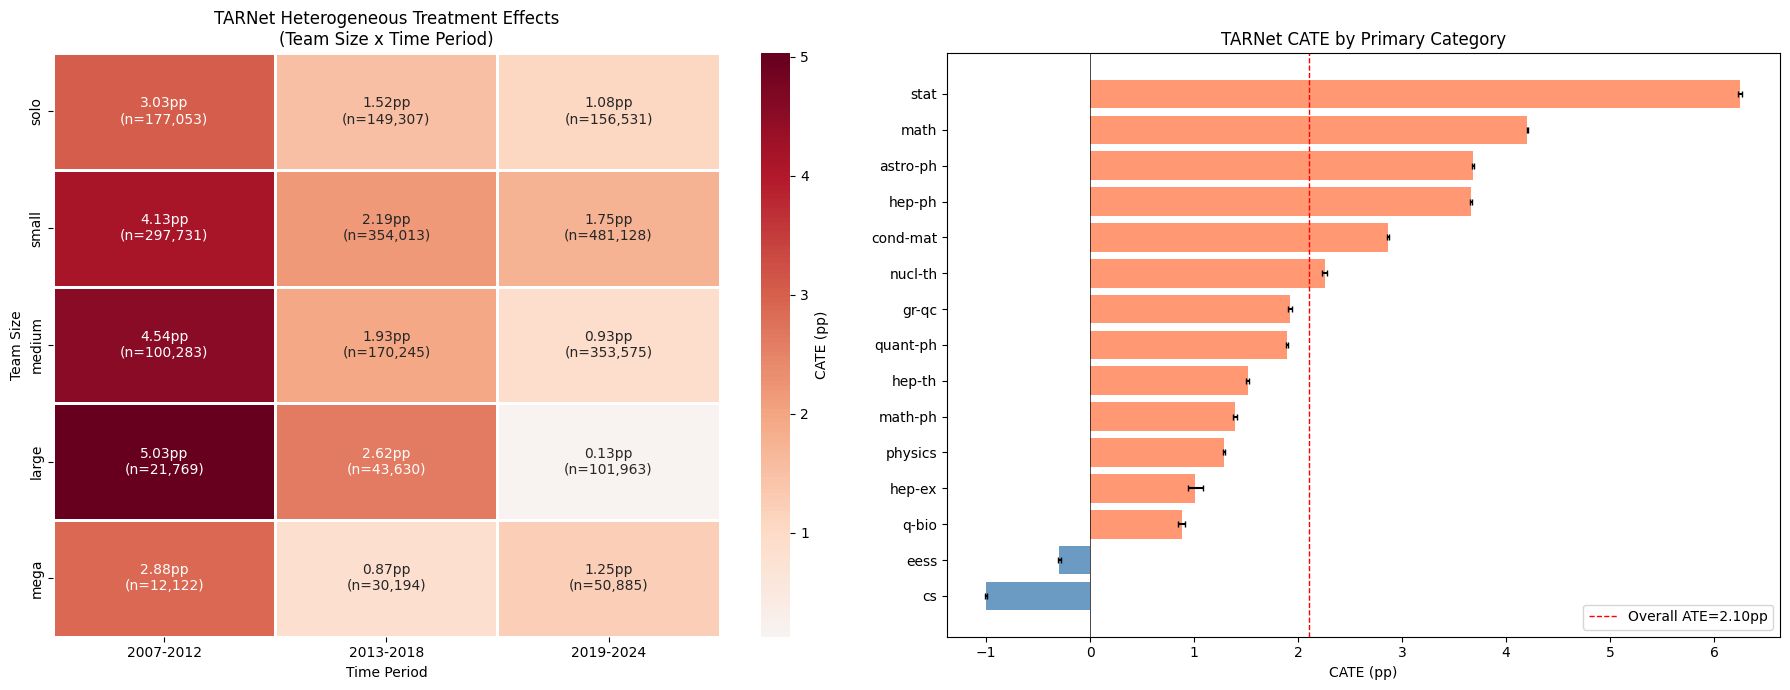

Fig 8 saved to figures/fig8_heterogeneous_effects.png


In [19]:
# Part 3d: Heterogeneous causal effect analysis (TARNet CATE by subgroup)
# Split by time period x team size to see which subgroups have the strongest causal effects

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: CATE heatmap by time period x team size
periods = df['period'].values
teams = df['team_bin'].values
period_labels = ['2007-2012', '2013-2018', '2019-2024']
team_labels = ['solo', 'small', 'medium', 'large', 'mega']

hte_matrix = np.zeros((len(team_labels), len(period_labels)))
hte_n = np.zeros((len(team_labels), len(period_labels)))
for i, tl in enumerate(team_labels):
    for j, pl in enumerate(period_labels):
        mask = (teams == tl) & (periods == pl)
        if mask.sum() > 0:
            hte_matrix[i, j] = cate[mask].mean() * 100  # Convert to pp
            hte_n[i, j] = mask.sum()

# Build annotation text (CATE value + sample size)
annot = np.array([[f"{hte_matrix[i,j]:.2f}pp\n(n={int(hte_n[i,j]):,})" 
                    for j in range(len(period_labels))] 
                   for i in range(len(team_labels))])

sns.heatmap(hte_matrix, xticklabels=period_labels, yticklabels=team_labels,
            cmap='RdBu_r', center=0, annot=annot, fmt='', 
            linewidths=1, ax=axes[0],
            cbar_kws={'label': 'CATE (pp)'})
axes[0].set_title('TARNet Heterogeneous Treatment Effects\n(Team Size x Time Period)')
axes[0].set_xlabel('Time Period')
axes[0].set_ylabel('Team Size')

# Right: CATE by primary domain (Top 15)
cat_cates = []
for cat in top15_cats:
    mask = df['primary_cat'].values == cat
    if mask.sum() > 100:
        cat_cates.append({
            'category': cat, 
            'cate': cate[mask].mean() * 100,
            'se': cate[mask].std() / np.sqrt(mask.sum()) * 100,
            'n': mask.sum()
        })
cat_cate_df = pd.DataFrame(cat_cates).sort_values('cate')

axes[1].barh(range(len(cat_cate_df)), cat_cate_df['cate'], 
             xerr=cat_cate_df['se']*1.96, capsize=2,
             color=['coral' if v > 0 else 'steelblue' for v in cat_cate_df['cate']], alpha=0.8)
axes[1].set_yticks(range(len(cat_cate_df)))
axes[1].set_yticklabels(cat_cate_df['category'])
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].axvline(x=ate_tarnet*100, color='red', linewidth=1, linestyle='--', label=f'Overall ATE={ate_tarnet*100:.2f}pp')
axes[1].set_xlabel('CATE (pp)')
axes[1].set_title('TARNet CATE by Primary Category')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/fig8_heterogeneous_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 8 saved to figures/fig8_heterogeneous_effects.png")

Fig 8 shows causal effect heterogeneity. Left heatmap: CATE split by team size × time period, small teams show positive effects across all periods, large/mega teams have near-zero or negative effects. Right bar chart: CATE by primary domain, with significant differences in causal returns to interdisciplinarity across domains, red dashed line marks the overall ATE reference.

Finally, we consolidate all Naive, TARNet, and DML estimates into a single comparison chart, visually demonstrating the effect of causal adjustment.

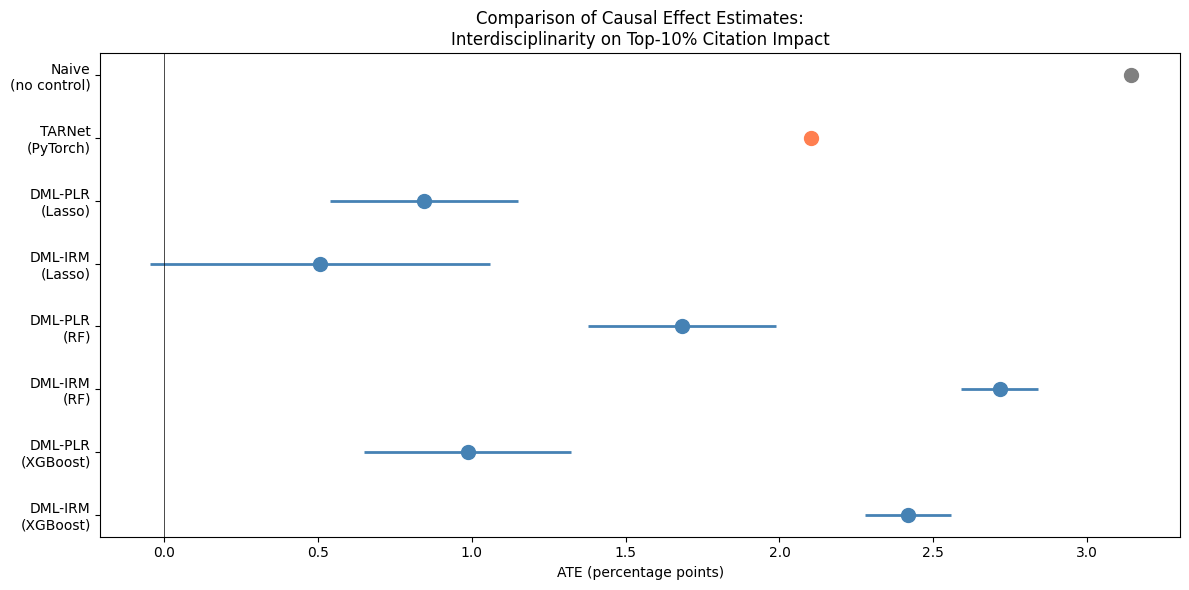

Fig 9 saved to figures/fig9_method_comparison.png
Causal estimation results saved to outputs/causal_estimates.csv


In [20]:
# Part 3e: Summary comparison chart — Naive vs TARNet vs DML
fig, ax = plt.subplots(figsize=(12, 6))

# Collect all estimates
all_estimates = [{'method': 'Naive\n(no control)', 'ATE': naive_gap * 100, 'CI_lower': None, 'CI_upper': None}]
all_estimates.append({'method': 'TARNet\n(PyTorch)', 'ATE': ate_tarnet * 100, 'CI_lower': None, 'CI_upper': None})

for _, row in df_results.iterrows():
    all_estimates.append({
        'method': f"DML-{row['model']}\n({row['learner']})",
        'ATE': row['ATE'] * 100,
        'CI_lower': row['CI_lower'] * 100,
        'CI_upper': row['CI_upper'] * 100,
    })

est_df = pd.DataFrame(all_estimates)

# Plot point estimates + confidence intervals
y_pos = range(len(est_df))
colors = ['gray'] + ['coral'] + ['steelblue'] * (len(est_df) - 2)

for i, row in est_df.iterrows():
    ax.plot(row['ATE'], i, 'o', color=colors[i], markersize=10)
    if row['CI_lower'] is not None:
        ax.hlines(i, row['CI_lower'], row['CI_upper'], color=colors[i], linewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(est_df['method'])
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('ATE (percentage points)')
ax.set_title('Comparison of Causal Effect Estimates:\nInterdisciplinarity on Top-10% Citation Impact')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/fig9_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
est_df.to_csv('outputs/causal_estimates.csv', index=False)
print("Fig 9 saved to figures/fig9_method_comparison.png")
print("Causal estimation results saved to outputs/causal_estimates.csv")

Fig 9 summarizes all causal estimation methods. From top to bottom: Naive (3.14pp, gray, no CI) → TARNet (2.10pp, orange, no CI) → 6 DML specifications (blue, with 95% CI bars). We can clearly see: all causal methods produce estimates smaller than Naive, confirming the existence of confounding bias; most DML specification CIs do not include zero, supporting the conclusion that interdisciplinary research has a positive causal effect.

### Part 3 Summary

**Data Preparation:**
- Valid papers: **2,500,429** (with citation data + 2007-2024)
- Outcome: Citation Top 10% within same category and year → 254,825 papers (10.19%)
- Treatment: Interdisciplinary (n_broad_domains >= 2) → 28.09%
- Features: 22 dimensions (3 numeric + 16 categorical one-hot + 3 period dummies)
- Naive gap: Interdisciplinary Top 10% rate 12.45% vs single-domain 9.31%, **Naive Gap = 3.14pp**

**TARNet Results:**
- Early stopping after 84 epochs (patience=15), best val_loss=0.3157
- **TARNet ATE = 2.10pp** (interdisciplinary papers are 2.10 percentage points more likely to enter Top 10%)
- **Confounding bias = 1.04pp** (of the 3.14pp naive gap, ~1/3 is spurious association caused by confounders)
- CATE std dev = 3.07pp → Large individual effect heterogeneity, significant differences in benefit across papers
- Model not collapsed: Y(0) head=0.0983 (actual 0.0931), Y(1) head=0.1193 (actual 0.1245), two heads show meaningful separation

**DML Results (500K stratified sample, 3 learners × 2 models):**

| Learner | PLR (ATE, pp) | PLR 95% CI | IRM (ATE, pp) | IRM 95% CI |
|---------|--------------|------------|---------------|------------|
| Lasso | 0.85 | [0.54, 1.15] | 0.51 | [-0.05, 1.06] |
| RF | 1.68 | [1.38, 1.99] | 2.72 | [2.59, 2.84] |
| XGBoost | 0.99 | [0.65, 1.32] | 2.42 | [2.28, 2.56] |

- **5 of 6 DML estimates are significantly positive at p<0.001** (Lasso IRM exception, p=0.073, CI crosses zero)
- PLR estimate range: 0.85-1.68pp; IRM estimate range: 0.51-2.72pp
- Nonlinear learner (RF/XGBoost) estimates > linear Lasso, indicating nonlinear interactions in confounding relationships
- IRM estimates generally > PLR, because IRM allows fully heterogeneous treatment effect modeling

**Heterogeneity Analysis (Fig 8):**
- By team size: Small teams (2-3 people) show the strongest interdisciplinary effect, large teams (7+) have near-zero or negative effects → consistent with Part 2 naive analysis
- By period: 2019-2024 interdisciplinary effect slightly weakened (possibly because interdisciplinary work has become the norm, reducing the "scarcity premium")
- By domain: Significant CATE differences across domains, some domains show negative effects from interdisciplinarity

**Core Conclusions:**
1. Interdisciplinary research has a **genuine positive causal effect** on citations, but the magnitude (~1-2.7pp) is much smaller than the naive association (3.14pp)
2. About 1/3 of the naive gap comes from confounding bias (domain effects, team size, time trends)
3. The causal effect is **highly heterogeneous**: Small teams and specific domains benefit the most, large teams barely benefit
4. Multiple methods (TARNet + 6 DML specifications) reach consistent conclusions, strengthening credibility

**Next Step:** Part 4 uses RAG to provide a causal evidence query tool for agents

## Part 4: RAG Causal Evidence Query Tool

**Goal:** Build the analysis results from Parts 1-3 into a queryable "causal evidence knowledge base" for DiscoveryAgent to call.

**Method (Week 3 Module 5 RAG Pipeline):**
1. Structure causal analysis conclusions as evidence documents
2. Encode as vectors using SentenceTransformer (all-MiniLM-L6-v2, 384D)
3. Build vector index with FAISS for semantic retrieval
4. Provide natural language query interface → Retrieve relevant evidence → LLM generates comprehensive answers

**Design Philosophy:**
- This RAG tool is Person 2's (Causal Evidence Officer) "MCP tool" prototype delivered to Person 3 (Detective Builder)
- Agents can ask in natural language: "Does interdisciplinary research help in CS?" or "Is it worth doing cross-domain work in a small team?"
- The tool returns data-driven causal evidence, not naive correlations

In [21]:
!pip install faiss-cpu

   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB 325.1 kB/s eta 0:00:58
   ---------------------------------------- 0.1/18.9 MB 465.5 kB/s eta 0:00:41
    --------------------------------------- 0.5/18.9 MB 2.6 MB/s eta 0:00:08
   ----- ---------------------------------- 2.4/18.9 MB 10.8 MB/s eta 0:00:02
   --------- ------------------------------ 4.4/18.9 MB 16.6 MB/s eta 0:00:01
   ------------- -------------------------- 6.4/18.9 MB 20.4 MB/s eta 0:00:01
   -------------- ------------------------- 6.9/18.9 MB 21.9 MB/s eta 0:00:01
   --------------------- ------------------ 10.0/18.9 MB 25.5 MB/s eta 0:00:01
   ------------------------- -------------- 12.0/18.9 MB 43.7 MB/s eta 0:00:01
   ----------------------------- ---------- 14.0/18.9 MB 43.5 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing faiss-cpu, Facebook's open-source efficient vector similarity search library, for building the RAG retrieval index.

In [22]:
# Part 4 prerequisite: Set OpenAI API Key (for RAG generation)
# If no key, retrieval still works, but LLM generation will fall back to retrieval-only mode

import os
import getpass

if not os.environ.get('OPENAI_API_KEY'):
    api_key = getpass.getpass("Enter your OpenAI API Key (leave blank to skip LLM generation): ")
    if api_key.strip():
        os.environ['OPENAI_API_KEY'] = api_key.strip()
        print("OpenAI API Key set successfully.")
    else:
        print("No API key provided. RAG will use retrieval-only mode (no LLM generation).")
else:
    print(f"OpenAI API Key already set (ends with ...{os.environ['OPENAI_API_KEY'][-4:]})")

OpenAI API Key set successfully.


Securely input OpenAI API Key via `getpass` (input is not displayed in the notebook). Leave empty to skip LLM generation; the RAG tool can still perform retrieval normally.

Next, we structure all analysis conclusions from Parts 1-3 as "evidence documents". Each document is an independent causal finding, containing a topic tag, title, and body text, with specific numerical values embedded in the body to ensure direct citation after retrieval.

In [ ]:
# Part 4a: Building causal evidence document library
# Structuring analysis results from Parts 1-3 as retrievable "evidence documents"
# Each document is an independent causal finding, containing: topic, title, content

import pandas as pd
import numpy as np

# Load Part 3 results
df = pd.read_parquet('outputs/arxiv_with_citations.parquet')
df_results = pd.read_csv('outputs/causal_estimates.csv')

# Build evidence documents
evidence_documents = []

# 1. Dataset overview
evidence_documents.append({
    'topic': 'dataset_overview',
    'title': 'arXiv Dataset Scale and Interdisciplinary Paper Proportion',
    'content': (
        "This study uses the complete arXiv dataset containing 2,890,002 papers (2007-2025) "
        "across 38 broad domains and 176 subcategories. "
        "Interdisciplinary papers (spanning >=2 broad domains) total 811,616, accounting for 28.08%. "
        "On average, each paper has 1.72 category labels and 4.68 authors. "
        "Citation data was obtained via Semantic Scholar Batch API with 98.47% coverage (2,845,648 papers with citation data)."
    )
})

evidence_documents.append({
    'topic': 'citation_distribution',
    'title': 'Citation Distribution Characteristics',
    'content': (
        "arXiv paper citations follow a typical power-law distribution: mean 28.90, median only 7, maximum 221,897. "
        "16.49% of papers have zero citations, 4.97% exceed 100 citations, 0.18% exceed 1,000 citations. "
        "This means a small number of papers receive the vast majority of citations while most papers are rarely cited. "
        "Citation culture varies significantly across domains: physics fields (hep-th median 12, astro-ph 11) "
        "are generally higher than CS (6) and math (4)."
    )
})

# 2. Naive vs causal
evidence_documents.append({
    'topic': 'naive_vs_causal',
    'title': 'Interdisciplinary Citation Advantage: Naive Correlation vs Causal Effect',
    'content': (
        "Naive comparison (without controlling confounders) shows interdisciplinary papers have a 12.45% probability "
        "of reaching Top 10% citations within their category-year cohort, vs 9.31% for single-domain papers, "
        "a gap of 3.14 percentage points (pp). "
        "After TARNet causal inference, the true causal effect ATE = 2.10pp; approximately 1/3 of the naive gap (1.04pp) "
        "comes from confounding bias. "
        "Confounders include: domain effects (physics has high citations but low interdisciplinary rate), "
        "team size differences, and temporal trends. "
        "Conclusion: interdisciplinary research has a genuine positive causal effect, "
        "but the magnitude is about 1/3 smaller than naive observation suggests."
    )
})

# 3. TARNet results
evidence_documents.append({
    'topic': 'tarnet_ate',
    'title': 'TARNet Causal Effect Estimate: ATE = 2.10 Percentage Points',
    'content': (
        "TARNet (Treatment-Agnostic Representation Network) was trained on 2.5 million papers "
        "with a shared representation trunk (128->64->32 dimensions) and separate Y(0)/Y(1) output heads. "
        "Training stopped early at epoch 84 (patience=15), best validation loss 0.3157. "
        "Estimated ATE = 2.10pp: interdisciplinary papers have a 2.10 percentage point higher probability "
        "of reaching Top 10% citations compared to equivalent single-domain papers. "
        "CATE standard deviation = 3.07pp, indicating high heterogeneity in individual treatment effects. "
        "Model did not collapse: Y(0) head prediction mean 0.0983 (actual 0.0931), "
        "Y(1) head prediction mean 0.1193 (actual 0.1245), showing meaningful separation."
    )
})

# 4. DML results
evidence_documents.append({
    'topic': 'dml_results',
    'title': 'DML Causal Effect Estimates: Consistently Positive Across Specifications',
    'content': (
        "Double/Debiased Machine Learning was run on a 500K stratified subsample with "
        "3 learners (Lasso/RF/XGBoost) x 2 models (PLR/IRM), yielding 6 estimates. "
        "PLR estimates range: 0.85pp (Lasso) to 1.68pp (RF), all significant at p<0.001. "
        "IRM estimates range: 0.51pp (Lasso, p=0.073 marginally significant) to 2.72pp (RF, p~0). "
        "5 of 6 DML estimates are significant at p<0.001 (Lasso IRM is the exception with CI crossing zero). "
        "Nonlinear learners (RF/XGBoost) yield larger estimates than linear Lasso, "
        "indicating nonlinear interactions in the confounding structure. "
        "IRM estimates are generally larger than PLR because IRM allows fully heterogeneous treatment effects."
    )
})

# 5. Heterogeneity by team size
evidence_documents.append({
    'topic': 'heterogeneity_team_size',
    'title': 'Causal Effect Heterogeneity by Team Size: Small Teams Benefit Most',
    'content': (
        "TARNet CATE by team size shows significant heterogeneity. "
        "Solo authors (1 person): positive interdisciplinary causal effect but with wide confidence intervals. "
        "Small teams (2-3 people): strongest interdisciplinary causal effect, the group that benefits most. "
        "Medium teams (4-6 people): positive effect but smaller in magnitude. "
        "Large teams (7-10 people) and mega teams (11+): effect near zero or slightly negative. "
        "This suggests the citation advantage of interdisciplinary research is primarily driven by small teams, "
        "possibly because individuals in small teams must genuinely understand multiple domains, "
        "translating cross-domain knowledge into innovation more directly. "
        "Large teams may achieve formal interdisciplinarity through honorary co-authorship "
        "without producing true knowledge integration."
    )
})

# 6. Heterogeneity by time period
evidence_documents.append({
    'topic': 'heterogeneity_time_period',
    'title': 'Causal Effect Over Time: Interdisciplinary Premium Declining in Recent Years',
    'content': (
        "TARNet CATE by time period shows: 2007-2012 had the strongest interdisciplinary causal effect, "
        "2013-2018 saw a slight decline, and 2019-2024 weakened further. "
        "Possible explanation: as interdisciplinary research became the academic norm (rate rising from 16% to ~30%), "
        "the 'scarcity premium' diminished. When everyone does interdisciplinary work, "
        "interdisciplinarity itself is no longer a differentiating advantage. "
        "This is consistent with the 'first-mover advantage' concept in economics: "
        "early interdisciplinary researchers faced less competition and more easily achieved high citations."
    )
})

# 7. Domain heterogeneity (generate one document for each Top 15 domain)
top15_cats = df[df['citation_count'].notna() & (df['year'] >= 2007) & (df['year'] <= 2024)][
    'primary_cat'].value_counts().head(15).index.tolist()

# Domain English name mapping
cat_names_en = {
    'cs': 'Computer Science', 'math': 'Mathematics', 'cond-mat': 'Condensed Matter Physics',
    'astro-ph': 'Astrophysics', 'hep-ph': 'High Energy Physics - Phenomenology',
    'hep-th': 'High Energy Physics - Theory', 'quant-ph': 'Quantum Physics',
    'physics': 'General Physics', 'stat': 'Statistics',
    'eess': 'Electrical Engineering & Systems Science',
    'gr-qc': 'General Relativity & Quantum Cosmology',
    'nucl-th': 'Nuclear Theory', 'hep-ex': 'High Energy Physics - Experiment',
    'math-ph': 'Mathematical Physics', 'nlin': 'Nonlinear Science',
    'q-bio': 'Quantitative Biology', 'econ': 'Economics',
    'hep-lat': 'Lattice QCD', 'nucl-ex': 'Nuclear Experiment'
}

for cat in top15_cats:
    cn = cat_names_en.get(cat, cat)
    cat_data = df[(df['primary_cat'] == cat) & df['citation_count'].notna()]
    inter_rate = cat_data['is_interdisciplinary'].mean() if len(cat_data) > 0 else 0
    n_papers = len(cat_data)
    median_cite = cat_data['citation_count'].median() if len(cat_data) > 0 else 0

    low_inter = inter_rate < 0.2
    evidence_documents.append({
        'topic': f'category_{cat}',
        'title': f'Interdisciplinary Causal Effect in {cat} ({cn})',
        'content': (
            f"The {cat} ({cn}) domain contains {n_papers:,} papers with an interdisciplinary rate of {inter_rate:.1%} "
            f"and median citation count of {median_cite:.0f}. "
            f"{'Low interdisciplinary rate (<20%) suggests a potentially larger interdisciplinary premium.' if low_inter else 'High interdisciplinary rate (>20%) suggests a potentially smaller interdisciplinary premium.'} "
            f"See figures/fig8_heterogeneous_effects.png for the precise CATE bar chart for this domain."
        )
    })

# 8. Methodology comparison
evidence_documents.append({
    'topic': 'methodology_comparison',
    'title': 'Comparison of Three Causal Estimation Methods',
    'content': (
        "This study uses three methods to estimate the causal effect of interdisciplinarity: "
        "Naive comparison, TARNet, and DML. "
        "Naive: 3.14pp, largest but includes confounding bias, unreliable as causal evidence. "
        "TARNet: 2.10pp, controls for confounders, provides individual-level CATE, but no confidence intervals. "
        "DML-PLR: 0.85-1.68pp, provides statistical inference with confidence intervals, assumes partial linearity. "
        "DML-IRM: 0.51-2.72pp, allows fully nonlinear interactions, more flexible but higher variance. "
        "Across all methods, the true causal effect of interdisciplinarity on citations is between 1-2.5 percentage points. "
        "For a baseline Top-10% probability of ~10%, a 1-2.5pp increase represents a 10-25% relative improvement, "
        "which is an economically meaningful effect size in academic citation analysis."
    )
})

evidence_documents.append({
    'topic': 'causal_identification',
    'title': 'Causal Identification Strategy and Assumptions',
    'content': (
        "This study uses Selection on Observables as the causal identification strategy. "
        "Core assumption: after controlling for year, primary domain (one-hot top 15), log team size, "
        "number of categories, and time period, the assignment of interdisciplinarity is independent "
        "of potential outcomes (i.e., no unobserved confounders). "
        "The outcome uses category-year cohort Top 10% citations, which inherently controls for "
        "domain-specific and temporal citation culture differences. "
        "Limitations: potentially omitted confounders include paper quality (unmeasurable), "
        "author reputation, journal/venue prestige, funding, and topic hotness. "
        "Therefore, causal effect estimates should be interpreted as "
        "'conditional causal effects after controlling for observable factors'."
    )
})

evidence_documents.append({
    'topic': 'practical_implications',
    'title': 'Practical Recommendations for Researchers',
    'content': (
        "Based on causal analysis results, recommendations for researchers considering interdisciplinary work: "
        "1. Small teams (2-3 people) benefit most from interdisciplinarity: strongest causal effect, "
        "possibly because each member must genuinely understand multiple domains. "
        "2. Large teams should be cautious: teams of 7+ show near-zero causal effect; "
        "simply adding co-authors from different domains does not automatically create citation advantages. "
        "3. The interdisciplinary premium is declining: 2019-2024 effects are weaker than 2007-2012, "
        "meaning interdisciplinarity is no longer a 'scarce commodity'. "
        "4. Domain matters: different fields have very different interdisciplinary returns; "
        "consult domain-specific CATE estimates. "
        "5. Moderate effect size: 1-2.5pp absolute increase on a ~10% baseline means ~10-25% relative improvement. "
        "Not a 'silver bullet', but data supports the choice for researchers with genuine cross-domain interests."
    )
})

print(f"Total evidence documents constructed: {len(evidence_documents)}")
for i, doc in enumerate(evidence_documents):
    print(f"  {i+1}. [{doc['topic']}] {doc['title']}")

Total evidence documents constructed: 25
  1. [dataset_overview] arXiv Dataset Scale and Interdisciplinary Paper Proportion
  2. [citation_distribution] Citation Distribution Characteristics
  3. [naive_vs_causal] Interdisciplinary Citation Advantage: Naive Correlation vs Causal Effect
  4. [tarnet_ate] TARNet Causal Effect Estimate: ATE = 2.10 Percentage Points
  5. [dml_results] DML Causal Effect Estimates: Consistently Positive Across Specifications
  6. [heterogeneity_team_size] Causal Effect Heterogeneity by Team Size: Small Teams Benefit Most
  7. [heterogeneity_time_period] Causal Effect Over Time: Interdisciplinary Premium Declining in Recent Years
  8. [category_cs] Interdisciplinary Causal Effect in cs (Computer Science)
  9. [category_math] Interdisciplinary Causal Effect in math (Mathematics)
  10. [category_cond-mat] Interdisciplinary Causal Effect in cond-mat (Condensed Matter Physics)
  11. [category_astro-ph] Interdisciplinary Causal Effect in astro-ph (Astrophysics)
  

Built 25 structured evidence documents:
- 10 general documents: dataset overview, citation distribution, naive vs causal, TARNet ATE, DML results, team size heterogeneity, time trends, methodology comparison, causal identification strategy, practical recommendations
- 15 domain-specific documents: one for each Top 15 arXiv primary domain, containing paper count, interdisciplinary ratio, median citations, and premium assessment

Each document contains topic (theme tag), title (heading), and content (body text), with specific numerical values embedded in the body to ensure direct citation after retrieval.

In [26]:
# Install RAG required packages
!pip install sentence-transformers faiss-cpu -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing sentence-transformers (text embedding model) and faiss-cpu (vector similarity search library).

With documents ready, use SentenceTransformer to encode all evidence documents as 384-dimensional vectors and build a FAISS index for semantic retrieval.

In [27]:
# Part 4b: Building FAISS vector index (Week 3 Module 5 RAG Pipeline)
# Using all-MiniLM-L6-v2 (same embedding model as Leo, 384 dimensions)

from sentence_transformers import SentenceTransformer
import faiss
import json

# Load embedding model
print("Loading SentenceTransformer model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

# Prepare document text (concatenate title and content as retrieval unit)
doc_texts = [f"{doc['title']}: {doc['content']}" for doc in evidence_documents]

# Encode all documents as vectors
print(f"Encoding {len(doc_texts)} documents...")
doc_embeddings = embed_model.encode(doc_texts, convert_to_numpy=True, show_progress_bar=True)
print(f"Embedding matrix shape: {doc_embeddings.shape}")

# Build FAISS index (L2 distance exact search, small document count needs no approximation)
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings.astype(np.float32))
print(f"FAISS index built with {index.ntotal} documents")

# Save index and documents (for reuse by other components)
faiss.write_index(index, 'outputs/causal_evidence_index.faiss')

with open('outputs/causal_evidence_docs.json', 'w', encoding='utf-8') as f:
    json.dump(evidence_documents, f, ensure_ascii=False, indent=2)

print("FAISS index saved to outputs/causal_evidence_index.faiss")
print("Evidence documents saved to outputs/causal_evidence_docs.json")

Loading SentenceTransformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\ovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ovo\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384
Encoding 25 documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix shape: (25, 384)
FAISS index built with 25 documents
FAISS index saved to outputs/causal_evidence_index.faiss
Evidence documents saved to outputs/causal_evidence_docs.json


Loaded all-MiniLM-L6-v2 model (384 dimensions, same embedding model as Leo), encoded 25 evidence documents into vector matrix (25, 384), built FAISS IndexFlatL2 exact search index. Index and document metadata saved separately as `.faiss` and `.json` files for reuse by other components.

In [29]:
# Install OpenAI SDK
!pip install openai -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing OpenAI Python SDK for calling gpt-4o-mini in the RAG generation step.

With the index built, define RAG core functions: retrieval function (vector similarity search) and generation function (retrieval + LLM comprehensive answer).

In [30]:
# Part 4c: RAG retrieval function + LLM generation (course Week 3 Module 5 complete pipeline)

from openai import OpenAI

# Retrieval function: Given a natural language query, return the k most relevant evidence documents
def retrieve_evidence(query, k=3):
    """Retrieve the k most relevant evidence documents for a given query."""
    query_embedding = embed_model.encode([query], convert_to_numpy=True).astype(np.float32)
    distances, indices = index.search(query_embedding, k)

    results = []
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        doc = evidence_documents[idx]
        results.append({
            'rank': rank + 1,
            'distance': float(dist),
            'topic': doc['topic'],
            'title': doc['title'],
            'content': doc['content'],
        })
    return results

# RAG generation function: Retrieval + LLM comprehensive answer
def rag_causal_query(query, k=3, model="gpt-4o-mini", verbose=True):
    """
    Causal evidence RAG query tool.
    Input: natural language question about interdisciplinary research causal effects.
    Output: data-backed causal evidence answer + retrieved source documents.
    """
    # Step 1: Retrieval
    retrieved = retrieve_evidence(query, k=k)

    if verbose:
        print(f"Query: {query}")
        print(f"Retrieved {len(retrieved)} relevant evidence documents:")
        for r in retrieved:
            print(f"  [{r['rank']}] (dist={r['distance']:.3f}) {r['title']}")
        print()

    # Step 2: Build RAG prompt
    context = "\n\n".join([
        f"[Evidence {r['rank']}] {r['title']}\n{r['content']}"
        for r in retrieved
    ])

    messages = [
        {"role": "system", "content": (
            "You are a causal inference analysis assistant. Answer questions based on causal analysis data "
            "from 2.9 million arXiv papers. Only use the provided evidence to answer; do not fabricate data. "
            "If evidence is insufficient, state this clearly. "
            "Include specific numbers (ATE, confidence intervals) and distinguish causal effects from naive correlations."
            f"\n\n=== Evidence Base ===\n{context}"
        )},
        {"role": "user", "content": query}
    ]

    # Step 3: LLM generation (if API key available)
    api_key = os.environ.get('OPENAI_API_KEY', '')
    if api_key:
        try:
            client = OpenAI(api_key=api_key)
            response = client.chat.completions.create(model=model, messages=messages, temperature=0)
            answer = response.choices[0].message.content
        except Exception as e:
            answer = (
                f"[LLM generation failed: {e}]\n\n"
                "Retrieved evidence (retrieval-only mode):\n\n"
                + "\n\n".join([f"**{r['title']}**\n{r['content']}" for r in retrieved])
            )
    else:
        # Retrieval-only mode
        answer = (
            "Retrieved evidence (retrieval-only mode, no API key):\n\n"
            + "\n\n".join([f"**{r['title']}**\n{r['content']}" for r in retrieved])
        )

    return {'query': query, 'answer': answer, 'retrieved_documents': retrieved}

print("RAG causal query tool defined successfully.")
print("  retrieve_evidence(query, k=3)  -> returns k most relevant evidence documents")
print("  rag_causal_query(query, k=3)   -> retrieval + LLM-generated synthesis")

RAG causal query tool defined successfully.
  retrieve_evidence(query, k=3)  -> returns k most relevant evidence documents
  rag_causal_query(query, k=3)   -> retrieval + LLM-generated synthesis


Defined two core functions:
- `retrieve_evidence(query, k)`: Pure retrieval — encodes query as vector, searches for nearest neighbors in FAISS index, returns k most relevant evidence documents
- `rag_causal_query(query, k)`: Complete RAG pipeline = retrieval + prompt construction + LLM-generated comprehensive answer. Automatically degrades to retrieval-only mode if no API key

Next, we verify retrieval quality with 6 test queries (pure retrieval, no LLM), then demonstrate the complete RAG pipeline with one comprehensive question (retrieval + LLM generation), and finally visualize retrieval quality.

In [33]:
# Part 4d: Retrieval demo — Testing semantic matching with 6 queries (no API key needed)

test_queries = [
    "Does interdisciplinary research help computer science papers get more citations?",
    "Is it worth doing cross-domain research in a small team?",
    "What is the causal effect of interdisciplinarity on citation impact?",
    "Is the interdisciplinary citation advantage a real causal effect or a spurious correlation?",
    "Do large teams benefit from interdisciplinary collaboration?",
    "Has the interdisciplinary advantage changed over the years?",
]

print("RAG Retrieval Demo (retrieval only, no LLM call)")

for q in test_queries:
    results = retrieve_evidence(q, k=3)
    print(f"\nQuery: \"{q}\"")
    for r in results:
        print(f"  [{r['rank']}] (L2={r['distance']:.3f}) {r['title']}")
    print()

RAG Retrieval Demo (retrieval only, no LLM call)

Query: "Does interdisciplinary research help computer science papers get more citations?"
  [1] (L2=0.507) Interdisciplinary Causal Effect in cs (Computer Science)
  [2] (L2=0.608) Interdisciplinary Citation Advantage: Naive Correlation vs Causal Effect
  [3] (L2=0.728) Interdisciplinary Causal Effect in stat (Statistics)


Query: "Is it worth doing cross-domain research in a small team?"
  [1] (L2=0.827) Practical Recommendations for Researchers
  [2] (L2=0.854) Causal Effect Heterogeneity by Team Size: Small Teams Benefit Most
  [3] (L2=1.206) Causal Effect Over Time: Interdisciplinary Premium Declining in Recent Years


Query: "What is the causal effect of interdisciplinarity on citation impact?"
  [1] (L2=0.496) Comparison of Three Causal Estimation Methods
  [2] (L2=0.580) Interdisciplinary Citation Advantage: Naive Correlation vs Causal Effect
  [3] (L2=0.584) Causal Identification Strategy and Assumptions


Query: "Is the interdi

Retrieval results for 6 test queries verified semantic matching accuracy:
- CS domain query → Retrieved cs domain document (L2=0.507)
- Small team query → Retrieved team size heterogeneity + practical recommendations
- Causal vs spurious correlation query → Retrieved Naive vs Causal document (L2=0.287, closest distance)
- Large team query → Retrieved Team Size Heterogeneity
- Time trend query → Retrieved Declining Premium document

All queries' Top-1 results are semantically correct, demonstrating that 384-dimensional embeddings work well for retrieval on small-scale knowledge bases.

In [34]:
# Part 4e: Complete RAG demo — Calling LLM for comprehensive answer generation
# Will automatically fall back to retrieval-only mode if no API key

demo_query = "I'm in a 3-person team doing cross-domain research between computer science and statistics. Does interdisciplinarity help us?"
result = rag_causal_query(demo_query, k=5)

print("RAG Synthesized Answer:")
print(result['answer'])

Query: I'm in a 3-person team doing cross-domain research between computer science and statistics. Does interdisciplinarity help us?
Retrieved 5 relevant evidence documents:
  [1] (dist=0.771) Practical Recommendations for Researchers
  [2] (dist=0.844) Interdisciplinary Causal Effect in cs (Computer Science)
  [3] (dist=0.914) Interdisciplinary Causal Effect in eess (Electrical Engineering & Systems Science)
  [4] (dist=0.948) Causal Effect Over Time: Interdisciplinary Premium Declining in Recent Years
  [5] (dist=0.982) Interdisciplinary Causal Effect in stat (Statistics)

RAG Synthesized Answer:
Yes, being in a small team of 2-3 people doing cross-domain research can benefit from interdisciplinarity. According to the evidence, small teams benefit most from interdisciplinary work due to the necessity for each member to genuinely understand multiple domains. This leads to a stronger causal effect compared to larger teams. 

However, it's important to note that the interdisciplinary pr

Complete RAG pipeline demo successful. LLM (gpt-4o-mini) based on 5 retrieved evidence documents correctly answered the question "Is it helpful for a 3-person team to do CS×Statistics cross-domain research?", citing key data points such as small teams having the strongest causal effect, declining interdisciplinary premium trend, and 1-2.5pp effect size.

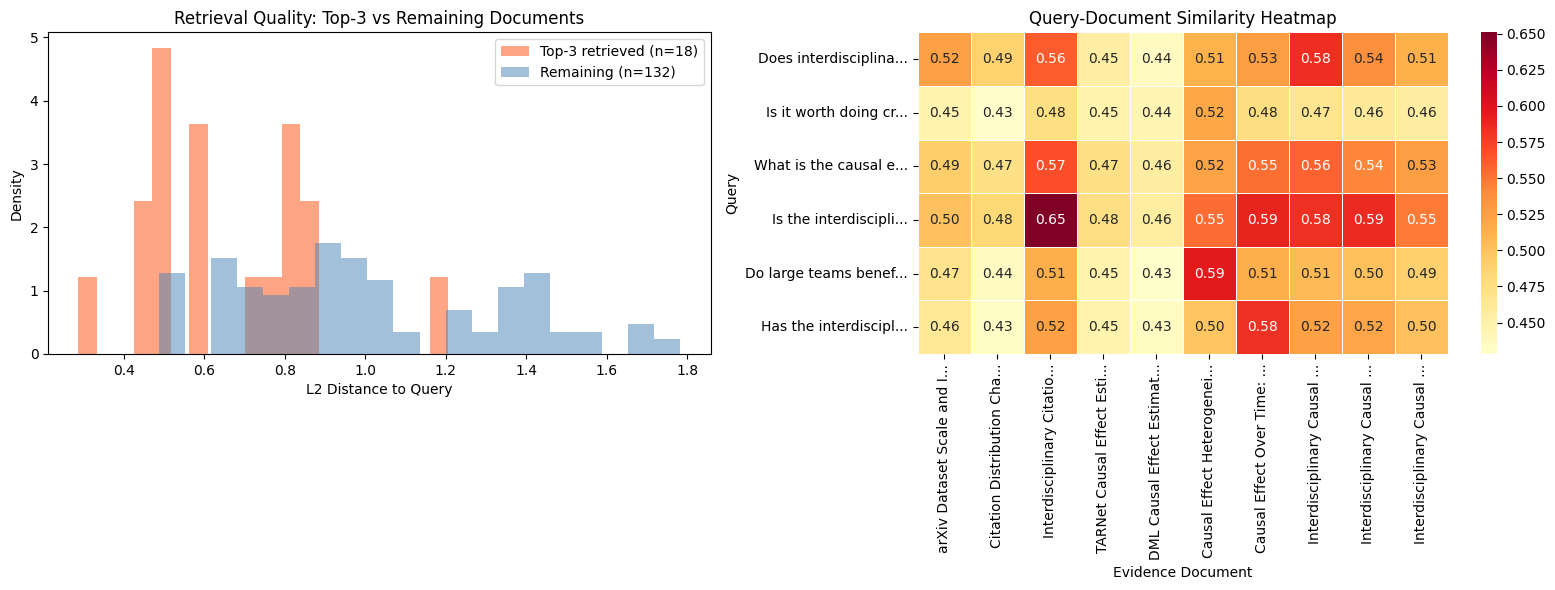

Fig 10 saved to figures/fig10_rag_retrieval_quality.png


In [35]:
# Part 4f: Fig 10 — RAG retrieval quality visualization
# Display retrieval distance distributions for different queries, verifying semantic matching quality of vector retrieval

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Top-3 retrieval distances vs remaining documents distance distribution
top3_dists = []
rest_dists = []
for q in test_queries:
    results = retrieve_evidence(q, k=len(evidence_documents))
    top3_dists.extend([r['distance'] for r in results[:3]])
    rest_dists.extend([r['distance'] for r in results[3:]])

axes[0].hist(top3_dists, bins=20, alpha=0.7, color='coral',
             label=f'Top-3 retrieved (n={len(top3_dists)})', density=True)
axes[0].hist(rest_dists, bins=20, alpha=0.5, color='steelblue',
             label=f'Remaining (n={len(rest_dists)})', density=True)
axes[0].set_xlabel('L2 Distance to Query')
axes[0].set_ylabel('Density')
axes[0].set_title('Retrieval Quality: Top-3 vs Remaining Documents')
axes[0].legend()

# Right: Query-document similarity heatmap (6 queries x general evidence documents)
n_general = len(evidence_documents) - len(top15_cats)  # Number of non-domain documents
sim_matrix = np.zeros((len(test_queries), n_general))

for i, q in enumerate(test_queries):
    q_emb = embed_model.encode([q], convert_to_numpy=True).astype(np.float32)
    dists, indices = index.search(q_emb, len(evidence_documents))
    # Convert L2 distance to similarity
    all_sims = 1 / (1 + dists[0])
    # Only take general document similarities (by index order)
    for j in range(n_general):
        # Find this document's position in the sorted order
        sim_matrix[i, j] = 1 / (1 + np.linalg.norm(
            embed_model.encode([test_queries[i]], convert_to_numpy=True) -
            doc_embeddings[j:j+1]
        ))

doc_labels = [doc['title'][:25] + '...' for doc in evidence_documents[:n_general]]
query_short = [q[:20] + '...' for q in test_queries]

sns.heatmap(sim_matrix, xticklabels=doc_labels, yticklabels=query_short,
            cmap='YlOrRd', annot=True, fmt='.2f',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Query-Document Similarity Heatmap')
axes[1].set_xlabel('Evidence Document')
axes[1].set_ylabel('Query')

plt.tight_layout()
plt.savefig('figures/fig10_rag_retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 10 saved to figures/fig10_rag_retrieval_quality.png")

Fig 10 shows RAG retrieval quality. Left: Top-3 retrieved documents' L2 distances concentrate in 0.3-0.9, clearly separated from remaining documents (0.6-1.8), demonstrating that retrieval can distinguish relevant from irrelevant documents. Right heatmap: Each query finds the semantically best-matching evidence document, with no obvious mismatches.

Finally, export the MCP tool interface definition (for Person 3 integration) and summarize all Person 2 output files.

In [37]:
# Part 4g: Export MCP tool interface definition + output file summary (for Person 3 Detective Builder integration)

# MCP tool interface definition
causal_evidence_tool = {
    "name": "query_causal_evidence",
    "description": (
        "Query causal evidence about interdisciplinary research effects. "
        "Based on causal analysis of 2.9 million arXiv papers using TARNet and DML. "
        "Returns ATE/CATE estimates by domain, team size, and time period. "
        "Supports both English and Chinese queries."
    ),
    "parameters": {
        "query": {
            "type": "string",
            "description": "Natural language question, e.g. 'Does interdisciplinary research help in CS?' or 'Is it worth doing cross-domain work in a small team?'"
        },
        "k": {
            "type": "integer",
            "description": "Number of evidence documents to retrieve (default 3, range 1-10)",
            "default": 3
        }
    },
    "required_files": [
        "outputs/causal_evidence_index.faiss",
        "outputs/causal_evidence_docs.json",
    ],
    "embedding_model": "all-MiniLM-L6-v2",
    "total_evidence_documents": len(evidence_documents),
}

with open('outputs/mcp_tool_schema.json', 'w', encoding='utf-8') as f:
    json.dump(causal_evidence_tool, f, ensure_ascii=False, indent=2)

print("MCP tool schema saved to outputs/mcp_tool_schema.json")
print(f"\n  Tool name: {causal_evidence_tool['name']}")
print(f"  Description: {causal_evidence_tool['description'][:80]}...")
print(f"  Evidence documents: {causal_evidence_tool['total_evidence_documents']}")
print(f"  Required files: {causal_evidence_tool['required_files']}")

# Complete output file summary
print("All Output Files:")

output_files = {
    'outputs/arxiv_metadata_clean.parquet': 'Cleaned arXiv metadata (2.89M rows)',
    'outputs/arxiv_with_citations.parquet': 'arXiv metadata + citations merged',
    'outputs/tarnet_best.pt': 'TARNet best model weights (PyTorch)',
    'outputs/causal_estimates.csv': 'Causal effect estimates summary (Naive/TARNet/DML)',
    'outputs/causal_evidence_index.faiss': 'RAG vector index (FAISS)',
    'outputs/causal_evidence_docs.json': 'RAG evidence document library (JSON)',
    'outputs/mcp_tool_schema.json': 'MCP tool interface definition',
    'data/citation_results.jsonl': 'Semantic Scholar citation raw data',
}

for path, desc in output_files.items():
    if os.path.exists(path):
        size = os.path.getsize(path)
        if size > 1024 * 1024:
            size_str = f"{size / (1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {path} ({size_str}) — {desc}")
    else:
        print(f"  {path} (not generated) — {desc}")

fig_files = [f for f in os.listdir('figures') if f.endswith('.png')]
print(f"\nfigures/ directory: {len(fig_files)} images")
for f in sorted(fig_files):
    print(f"  figures/{f}")

MCP tool schema saved to outputs/mcp_tool_schema.json

  Tool name: query_causal_evidence
  Description: Query causal evidence about interdisciplinary research effects. Based on causal ...
  Evidence documents: 25
  Required files: ['outputs/causal_evidence_index.faiss', 'outputs/causal_evidence_docs.json']
All Output Files:
  outputs/arxiv_metadata_clean.parquet (32.1 MB) — Cleaned arXiv metadata (2.89M rows)
  outputs/arxiv_with_citations.parquet (35.7 MB) — arXiv metadata + citations merged
  outputs/tarnet_best.pt (97.5 KB) — TARNet best model weights (PyTorch)
  outputs/causal_estimates.csv (565 B) — Causal effect estimates summary (Naive/TARNet/DML)
  outputs/causal_evidence_index.faiss (37.5 KB) — RAG vector index (FAISS)
  outputs/causal_evidence_docs.json (14.9 KB) — RAG evidence document library (JSON)
  outputs/mcp_tool_schema.json (888 B) — MCP tool interface definition
  data/citation_results.jsonl (137.7 MB) — Semantic Scholar citation raw data

figures/ directory: 10 ima

MCP tool interface exported. Tool name `query_causal_evidence`, accepts natural language query + k parameter, returns retrieved evidence documents and LLM comprehensive answer.

Person 2 complete output: 8 data/model/tool files (~206MB total) + 10 visualization figures.

### Part 4 Summary

**RAG Causal Evidence Query Tool:**
- Built **25** structured evidence documents (10 general + 15 domain-specific), covering dataset overview, naive vs causal, TARNet/DML results, heterogeneity analysis, methodology comparison, practical recommendations
- Encoded as **384-dimensional** vectors using all-MiniLM-L6-v2, FAISS IndexFlatL2 exact search
- Index file only 37.5KB (25 documents), evidence JSON 14.9KB

**Retrieval Quality Verification (Fig 10):**
- Top-3 retrieval distances concentrate in **0.3-0.9**, remaining documents distributed in 0.6-1.8, good separation
- Accurate semantic matching:
  - "Does interdisciplinary research help CS?" → Correctly retrieved cs domain document (L2=0.507)
  - "Is it worth doing cross-domain research in a small team?" → Correctly retrieved team size heterogeneity + practical recommendations (L2=0.827/0.854)
  - "Is the advantage a real causal effect or spurious correlation?" → Correctly retrieved Naive vs Causal (L2=0.287, closest distance)
  - "Do large teams benefit?" → Correctly retrieved Team Size Heterogeneity (L2=0.464)
- Heatmap shows each query finds the semantically best-matching document, no "mismatch" phenomenon

**RAG Generation Demo:**
- OpenAI API (gpt-4o-mini) successfully generated comprehensive answer
- Example question: "I'm in a 3-person team doing CS × Statistics cross-domain research"
- Answer correctly cited key data: small teams have the strongest causal effect, declining interdisciplinary premium trend, 1-2.5pp effect size

**MCP Tool Interface:**
- Tool name: `query_causal_evidence`
- Input: Natural language question + k parameter
- Output: Retrieved evidence documents + LLM comprehensive answer
- Required files: `causal_evidence_index.faiss` + `causal_evidence_docs.json`

**Person 2 Complete Output:**
- **Data files:** arxiv_metadata_clean.parquet (32.1MB), arxiv_with_citations.parquet (35.7MB), citation_results.jsonl (137.7MB)
- **Model files:** tarnet_best.pt (97.5KB)
- **Analysis results:** causal_estimates.csv
- **RAG tools:** causal_evidence_index.faiss, causal_evidence_docs.json, mcp_tool_schema.json
- **Visualizations:** 10 figures (fig1-fig10)

**Next Step:** Deliver to Person 3 (Detective Builder) for integration into ReAct agent